<a href="https://colab.research.google.com/github/John-Buttell/March-Madness-Prediction-Machine-Learning-Project/blob/main/Copy_of_573_Project_BBall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standard Import

In [ ]:
# =============================================================================
#                    STANDARD IMPORT — Men's Data Only
# =============================================================================
#
# PURPOSE:
#   This cell loads ALL of the data our group needs for the project.
#   Every group member should run this cell first, then use the variable
#   names defined here in their own model section. This way we all work
#   from the same data and can read each other's code easily.
#
# IMPORTANT — OUR PROJECT vs. THE KAGGLE COMPETITION:
#   The Kaggle competition predicts BOTH men's AND women's outcomes.
#   Our project focuses ONLY on men's tournament outcomes, so we only
#   load files that start with "M" (men's prefix). We ignore all "W"
#   (women's prefix) files entirely.
#
# =============================================================================
# DATA ACCESS — The data is already shared with everyone via Google Drive.
#
#   Shared folder link (view/edit access):
#   https://drive.google.com/drive/folders/1TrAjXhYim67iNNcjixcMNZLeWtDASFQ0
#
#   SETUP (one time only):
#     1. Open the link above in your browser
#     2. In Google Drive, right-click the "CS5730_Data" folder
#     3. Click "Organize" -> "Add shortcut to Drive" -> choose "My Drive"
#     4. Done! The code below will find it automatically.
#
#   If you prefer to download the data yourself instead:
#     - Kaggle website: "Download All" button on the competition data page
#     - Kaggle CLI:   !kaggle competitions download -c march-machine-learning-mania-2026
#     - kagglehub:    import kagglehub; kagglehub.competition_download('march-machine-learning-mania-2026')
#     Then set DATA_DIR below to point at your local CSV folder.
# =============================================================================


# ---- Standard Python libraries ----
import pandas as pd   # DataFrames for tabular data
import numpy as np    # Numerical operations (arrays, math, random)
import os             # File path handling

# ---- Reproducibility seed ----
# We use the course number (573) so all group members get identical results.
# Use this SEED anywhere you need randomness (splits, model init, etc.)
SEED = 573
np.random.seed(SEED)


# ---- Connect to the shared Google Drive folder ----
# This mounts your Google Drive so Colab can read files from it.
# You will see a popup asking you to sign in — just allow access.
from google.colab import drive
drive.mount('/content/drive')

# Points to the shared "CS5730_Data" folder (after you added the shortcut above).
# If you downloaded data locally instead, change this path to your CSV folder.
DATA_DIR = '/content/drive/MyDrive/CS5730_Data/'


def load(filename):
    # Helper: loads a CSV file from our data folder.
    # Just pass the filename like "MTeams.csv" and it handles the path.
    return pd.read_csv(os.path.join(DATA_DIR, filename))


# =============================================================================
# 1. TEAM & SEASON REFERENCE TABLES
#    Lookup tables to map IDs to names, find conferences, coaches, etc.
# =============================================================================

# teams: One row per team. Key columns: TeamID, TeamName
#   Example: TeamID 1181 = Duke (this ID never changes across seasons)
teams = load("MTeams.csv")

# seasons: One row per season. Key columns: Season (year), DayZero (date ref)
#   "Season" = year the tournament was played (e.g., 2024 = the 2023-24 season)
#   All game dates use "DayNum" (offset from DayZero), not calendar dates.
seasons = load("MSeasons.csv")

# conferences: Maps abbreviations to full names. Example: "B10" -> "Big Ten"
conferences = load("Conferences.csv")

# team_conferences: Which conference each team was in each season.
#   Teams can switch conferences — this tracks the full history.
team_conferences = load("MTeamConferences.csv")

# coaches: Head coach for each team each season.
#   If mid-season coaching change occurred, the team has multiple rows.
coaches = load("MTeamCoaches.csv")


# =============================================================================
# 2. TOURNAMENT SEEDS
#    Every team in the 68-team NCAA tournament gets a seed (1 through 16)
#    within one of four regions (W, X, Y, Z).
#    1-seed = best, 16-seed = worst. Seed diff is one of the strongest predictors.
# =============================================================================

seeds = load("MNCAATourneySeeds.csv")

# Raw "Seed" column: strings like "W01", "X14", "Z16a"
#   1st char = region (W/X/Y/Z), next 2 = seed number, optional 4th = play-in
# We extract just the number (1-16) into "SeedNum" for easy use in models.
#   Examples: "W01" -> 1,  "X14" -> 14,  "Z16a" -> 16
seeds["SeedNum"] = seeds["Seed"].str[1:3].astype(int)


# =============================================================================
# 3. GAME RESULTS — DETAILED (Full Box Scores, 2003 onward)
#
#    Main files for building features. Each row = one game with complete
#    box score stats for BOTH teams.
#
#    COLUMN NAMING: "W" prefix = WINNING team, "L" prefix = LOSING team
#      (NOT women/league — winner/loser!)
#
#    STAT COLUMNS (same set for both W and L):
#      FGM/FGA   = Field Goals Made/Attempted (includes 2pt AND 3pt)
#      FGM3/FGA3 = Three-Pointers Made/Attempted
#      FTM/FTA   = Free Throws Made/Attempted
#      OR/DR     = Offensive/Defensive Rebounds
#      Ast       = Assists
#      TO        = Turnovers
#      Stl       = Steals
#      Blk       = Blocks
#      PF        = Personal Fouls
#
#    USEFUL FORMULAS:
#      Two-point FG made = FGM - FGM3
#      Total points      = (2 * FGM) + FGM3 + FTM
#      Total rebounds    = OR + DR
# =============================================================================

# reg_season: ~110,000 regular season games with full box scores
reg_season = load("MRegularSeasonDetailedResults.csv")

# tourney: ~1,400 NCAA tournament games with full box scores
tourney = load("MNCAATourneyDetailedResults.csv")


# =============================================================================
# 4. GAME RESULTS — COMPACT (Final Scores Only, 1985 onward)
#    Same games but only the final score — no box score detail.
#    Goes back further (1985 vs 2003). Useful for longer historical windows.
#
#    Key columns: Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT
#      WLoc: "H"=home win, "A"=away win, "N"=neutral (all tourney games)
#      NumOT: overtime periods (0=regulation)
# =============================================================================

reg_season_compact = load("MRegularSeasonCompactResults.csv")
tourney_compact    = load("MNCAATourneyCompactResults.csv")


# =============================================================================
# 5. MASSEY ORDINAL RANKINGS
#    Weekly power rankings from dozens of systems (Pomeroy, Sagarin, RPI, ESPN).
#    Each row: "In season S, on day D, system R ranked team T as #N."
#
#    Key columns: Season, RankingDayNum, SystemName, TeamID, OrdinalRank
#    LARGE file (millions of rows). We typically use only the final pre-tourney
#    rankings (day 133) averaged across all systems.
# =============================================================================

ordinals = load("MMasseyOrdinals.csv")


# =============================================================================
# 6. MATCHUP FORMAT REFERENCE (Sample Submission File)
#    We are NOT submitting to Kaggle. This file just defines the format:
#      ID: "SSSS_XXXX_YYYY" (XXXX = lower TeamID, YYYY = higher TeamID)
#      Pred: probability that the LOWER-ID team (XXXX) wins
#    Our labels follow this same convention. Optional — code works without it.
# =============================================================================

try:
    sample_sub = load("SampleSubmissionStage1.csv")
except FileNotFoundError:
    sample_sub = None
    print("Note: SampleSubmissionStage1.csv not found (optional, this is fine).")


# =============================================================================
# MINIMAL CLEANING
# =============================================================================

# Filter to 2003+ (the "box score era"). Before 2003 we only have final scores,
# no stats to build features from. Standardize on 2003+ everywhere.
reg_season         = reg_season[reg_season["Season"] >= 2003].reset_index(drop=True)
tourney            = tourney[tourney["Season"] >= 2003].reset_index(drop=True)
reg_season_compact = reg_season_compact[reg_season_compact["Season"] >= 2003].reset_index(drop=True)
tourney_compact    = tourney_compact[tourney_compact["Season"] >= 2003].reset_index(drop=True)


# =============================================================================
# SANITY CHECK
# =============================================================================
print("=" * 55)
print("   DATA LOADED SUCCESSFULLY (Men's Only)")
print("=" * 55)
print(f"  teams              : {len(teams):>7,} rows   (team ID/name lookup)")
print(f"  seasons            : {len(seasons):>7,} rows   (season metadata)")
print(f"  seeds              : {len(seeds):>7,} rows   (tourney seeds, SeedNum 1-16)")
print(f"  reg_season         : {len(reg_season):>7,} rows   (regular season box scores)")
print(f"  tourney            : {len(tourney):>7,} rows   (tournament box scores)")
print(f"  reg_season_compact : {len(reg_season_compact):>7,} rows   (regular season scores)")
print(f"  tourney_compact    : {len(tourney_compact):>7,} rows   (tournament scores)")
print(f"  ordinals           : {len(ordinals):>7,} rows   (Massey rankings)")
print(f"  conferences        : {len(conferences):>7,} rows   (conference name lookup)")
print(f"  team_conferences   : {len(team_conferences):>7,} rows   (team->conference by season)")
print(f"  coaches            : {len(coaches):>7,} rows   (head coaches by season)")
print(f"  sample_sub         : {'loaded' if sample_sub is not None else 'not found (optional)'}")
print(f"  Seasons covered    : {reg_season['Season'].min()} - {reg_season['Season'].max()}")
print(f"  Random seed (SEED) : {SEED}")
print("=" * 55)

Mounted at /content/drive
   DATA LOADED SUCCESSFULLY (Men's Only)
  teams              :     381 rows   (team ID/name lookup)
  seasons            :      42 rows   (season metadata)
  seeds              :   2,694 rows   (tourney seeds, SeedNum 1-16)
  reg_season         : 124,529 rows   (regular season box scores)
  tourney            :   1,449 rows   (tournament box scores)
  reg_season_compact : 124,529 rows   (regular season scores)
  tourney_compact    :   1,449 rows   (tournament scores)
  ordinals           : 5,865,001 rows   (Massey rankings)
  conferences        :      51 rows   (conference name lookup)
  team_conferences   :  13,753 rows   (team->conference by season)
  coaches            :  13,900 rows   (head coaches by season)
  sample_sub         : loaded
  Seasons covered    : 2003 - 2026
  Random seed (SEED) : 573


## Feature Engineering — Season-Level Team Stats

The raw game data uses a **winner/loser format** (columns prefixed with `W` and `L`).
Before we can build features, we need to **reshape** this into a **team-perspective format**
where each row represents one team's performance in one game. Then we:

1. **Reshape** each game into two rows (one per team)
2. **Sum** each team's raw counting stats across their entire regular season
3. **Derive** advanced metrics from those totals (efficiency, shooting %, Four Factors, etc.)

The result is **`season_stats`** — one row per team per season with ~30 features.
These become the building blocks for matchup predictions.

In [ ]:
# =============================================================================
# FEATURE ENGINEERING — Build season-level stats for every team
# =============================================================================

# ---- STEP 1: Reshape game data from winner/loser to team perspective ----
#
# The raw data has columns like WFGM (winner's field goals) and LFGM (loser's).
# We flip this so each row is from ONE team's viewpoint.
# Each game becomes TWO rows: winner's perspective and loser's perspective.

def reshape_to_team_perspective(games_df):
    #
    # Convert winner/loser format into team-level format.
    # Input:  1 row per game (with W and L prefixed columns)
    # Output: 2 rows per game (one for each team's perspective)
    #

    # --- Build the winner's row ---
    winner = pd.DataFrame({
        'Season':   games_df['Season'].values,
        'DayNum':   games_df['DayNum'].values,
        'TeamID':   games_df['WTeamID'].values,     # This team's ID
        'OppID':    games_df['LTeamID'].values,     # Opponent's ID
        'Score':    games_df['WScore'].values,      # This team's points
        'OppScore': games_df['LScore'].values,      # Opponent's points
        # --- This team's box score ---
        'FGM':   games_df['WFGM'].values,    # Field goals made
        'FGA':   games_df['WFGA'].values,    # Field goals attempted
        'FGM3':  games_df['WFGM3'].values,   # Three-pointers made
        'FGA3':  games_df['WFGA3'].values,   # Three-pointers attempted
        'FTM':   games_df['WFTM'].values,    # Free throws made
        'FTA':   games_df['WFTA'].values,    # Free throws attempted
        'OR':    games_df['WOR'].values,     # Offensive rebounds
        'DR':    games_df['WDR'].values,     # Defensive rebounds
        'Ast':   games_df['WAst'].values,    # Assists
        'TO':    games_df['WTO'].values,     # Turnovers
        'Stl':   games_df['WStl'].values,    # Steals
        'Blk':   games_df['WBlk'].values,    # Blocks
        'PF':    games_df['WPF'].values,     # Personal fouls
        # --- Opponent's box score (needed for defensive metrics) ---
        'OppFGM':  games_df['LFGM'].values,
        'OppFGA':  games_df['LFGA'].values,
        'OppFGM3': games_df['LFGM3'].values,
        'OppFGA3': games_df['LFGA3'].values,
        'OppFTM':  games_df['LFTM'].values,
        'OppFTA':  games_df['LFTA'].values,
        'OppOR':   games_df['LOR'].values,
        'OppDR':   games_df['LDR'].values,
        'OppTO':   games_df['LTO'].values,
        'Win': 1  # This team won
    })

    # --- Build the loser's row (everything swapped) ---
    loser = pd.DataFrame({
        'Season':   games_df['Season'].values,
        'DayNum':   games_df['DayNum'].values,
        'TeamID':   games_df['LTeamID'].values,
        'OppID':    games_df['WTeamID'].values,
        'Score':    games_df['LScore'].values,
        'OppScore': games_df['WScore'].values,
        'FGM':   games_df['LFGM'].values,
        'FGA':   games_df['LFGA'].values,
        'FGM3':  games_df['LFGM3'].values,
        'FGA3':  games_df['LFGA3'].values,
        'FTM':   games_df['LFTM'].values,
        'FTA':   games_df['LFTA'].values,
        'OR':    games_df['LOR'].values,
        'DR':    games_df['LDR'].values,
        'Ast':   games_df['LAst'].values,
        'TO':    games_df['LTO'].values,
        'Stl':   games_df['LStl'].values,
        'Blk':   games_df['LBlk'].values,
        'PF':    games_df['LPF'].values,
        'OppFGM':  games_df['WFGM'].values,
        'OppFGA':  games_df['WFGA'].values,
        'OppFGM3': games_df['WFGM3'].values,
        'OppFGA3': games_df['WFGA3'].values,
        'OppFTM':  games_df['WFTM'].values,
        'OppFTA':  games_df['WFTA'].values,
        'OppOR':   games_df['WOR'].values,
        'OppDR':   games_df['WDR'].values,
        'OppTO':   games_df['WTO'].values,
        'Win': 0  # This team lost
    })

    return pd.concat([winner, loser], ignore_index=True)


# Reshape all regular season games
team_games = reshape_to_team_perspective(reg_season)
print(f"Reshaped {len(reg_season):,} games -> {len(team_games):,} team-game rows")


# ---- STEP 2: Sum counting stats across each team's full regular season ----
#
# We sum raw stats first, THEN compute percentages from the totals.
# This is more accurate than averaging per-game percentages because
# a game with 80 shots carries more weight than one with 50 shots.

sum_cols = [
    'Score', 'OppScore', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA',
    'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF',
    'OppFGM', 'OppFGA', 'OppFGM3', 'OppFGA3', 'OppFTM', 'OppFTA',
    'OppOR', 'OppDR', 'OppTO', 'Win'
]

season_totals = team_games.groupby(['Season', 'TeamID'])[sum_cols].sum().reset_index()
season_totals['Games'] = team_games.groupby(['Season', 'TeamID']).size().values


# ---- STEP 3: Compute derived features from season totals ----
#
# Categories:
#   - Basic performance (win%, scoring)
#   - Shooting efficiency (FG%, eFG%, TS%, etc.)
#   - Pace & efficiency ratings (points per 100 possessions)
#   - Dean Oliver's "Four Factors" of basketball success (offense AND defense)
#   - Per-game counting stats (rebounds, assists, steals, blocks, etc.)

season_stats = pd.DataFrame()
season_stats['Season'] = season_totals['Season']
season_stats['TeamID'] = season_totals['TeamID']

# -------------------------
# BASIC PERFORMANCE
# -------------------------
season_stats['WinPct']         = season_totals['Win'] / season_totals['Games']
season_stats['AvgScore']       = season_totals['Score'] / season_totals['Games']
season_stats['AvgOppScore']    = season_totals['OppScore'] / season_totals['Games']
season_stats['AvgScoreMargin'] = season_stats['AvgScore'] - season_stats['AvgOppScore']

# -------------------------
# HARDCODED DERIVED STATS
# -------------------------
# Two-point field goals per game
# (FGM includes BOTH 2pt and 3pt, so we subtract 3pt to isolate 2pt)
season_stats['AvgFGM2'] = (season_totals['FGM'] - season_totals['FGM3']) / season_totals['Games']

# -------------------------
# POSSESSIONS ESTIMATE (Dean Oliver's formula)
# -------------------------
# Possessions ~ FGA - OR + TO + 0.475 * FTA
# This estimates how many times a team had the ball per game.
# Needed to compute efficiency ratings that adjust for pace of play.
total_poss     = season_totals['FGA'] - season_totals['OR'] + season_totals['TO'] + 0.475 * season_totals['FTA']
opp_total_poss = season_totals['OppFGA'] - season_totals['OppOR'] + season_totals['OppTO'] + 0.475 * season_totals['OppFTA']

# -------------------------
# OFFENSIVE & DEFENSIVE EFFICIENCY
# -------------------------
# Points per 100 possessions — the gold standard for measuring team quality
# independent of how fast or slow a team plays.
# OffEff: higher = better offense.  DefEff: LOWER = better defense.
season_stats['OffEff'] = season_totals['Score'] / total_poss * 100
season_stats['DefEff'] = season_totals['OppScore'] / opp_total_poss * 100
season_stats['NetEff'] = season_stats['OffEff'] - season_stats['DefEff']

# -------------------------
# BASIC SHOOTING PERCENTAGES
# -------------------------
season_stats['FGPct']  = season_totals['FGM'] / season_totals['FGA']       # Overall FG%
season_stats['FG3Pct'] = season_totals['FGM3'] / season_totals['FGA3']     # 3-point FG%
season_stats['FTPct']  = season_totals['FTM'] / season_totals['FTA']       # Free throw %

# -------------------------
# ADVANCED SHOOTING EFFICIENCY
# -------------------------
# eFG% (Effective Field Goal %):
#   Gives 50% bonus credit for made 3-pointers.
#   Formula: (FGM + 0.5 * FGM3) / FGA
#   Better than raw FG% because it values 3-pointers more.
season_stats['eFGPct'] = (season_totals['FGM'] + 0.5 * season_totals['FGM3']) / season_totals['FGA']

# TS% (True Shooting %):
#   The most complete single measure of scoring efficiency.
#   Formula: Points / (2 * (FGA + 0.44 * FTA))
#   Accounts for 2pt, 3pt, AND free throws in one number.
season_stats['TSPct'] = season_totals['Score'] / (2 * (season_totals['FGA'] + 0.44 * season_totals['FTA']))

# 3PAr (Three-Point Attempt Rate): what fraction of shots are 3-pointers
season_stats['ThreePAr'] = season_totals['FGA3'] / season_totals['FGA']

# FTr (Free Throw Rate): how often a team gets to the line relative to FGA
season_stats['FTr'] = season_totals['FTA'] / season_totals['FGA']

# -------------------------
# DEAN OLIVER'S FOUR FACTORS (OFFENSE)
# -------------------------
# The four most important factors in winning basketball, per statistician
# Dean Oliver. Think of these as the "vital signs" of a basketball team.
#
#   Factor 1: eFGPct       — Shoot efficiently         (already computed above)
#   Factor 2: TORat        — Low turnover rate = good
#   Factor 3: ORPct        — Grab offensive rebounds for second chances
#   Factor 4: OliverFTRate — Get to the free throw line

# Turnover Rate: turnovers per possession (LOWER is better)
season_stats['TORat'] = season_totals['TO'] / total_poss

# Offensive Rebound %: what fraction of available offensive boards you grab
#   Available offensive rebounds = your OR + opponent's DR
season_stats['ORPct'] = season_totals['OR'] / (season_totals['OR'] + season_totals['OppDR'])

# Oliver's FT Rate: free throws MADE per field goal ATTEMPTED
season_stats['OliverFTRate'] = season_totals['FTM'] / season_totals['FGA']

# -------------------------
# DEAN OLIVER'S FOUR FACTORS (DEFENSE)
# -------------------------
# Same four factors from the opponent's perspective.
# Good defense = low opponent eFG%, high opponent TO rate,
# low opponent OR%, low opponent FT rate.

# Opponent eFG% — LOWER = your defense is better
season_stats['OppeFGPct'] = (season_totals['OppFGM'] + 0.5 * season_totals['OppFGM3']) / season_totals['OppFGA']

# Opponent TO Rate — HIGHER = you force more turnovers (good!)
season_stats['OppTORat'] = season_totals['OppTO'] / opp_total_poss

# Opponent OR% — LOWER = you limit their second chances (good!)
season_stats['OppORPct'] = season_totals['OppOR'] / (season_totals['OppOR'] + season_totals['DR'])

# Opponent FT Rate — LOWER = you keep them off the line (good!)
season_stats['OppOliverFTRate'] = season_totals['OppFTM'] / season_totals['OppFGA']

# -------------------------
# PER-GAME COUNTING STATS
# -------------------------
season_stats['AvgAst']      = season_totals['Ast'] / season_totals['Games']
season_stats['AvgTO']       = season_totals['TO'] / season_totals['Games']
season_stats['AvgStl']      = season_totals['Stl'] / season_totals['Games']
season_stats['AvgBlk']      = season_totals['Blk'] / season_totals['Games']
season_stats['AvgOR']       = season_totals['OR'] / season_totals['Games']
season_stats['AvgDR']       = season_totals['DR'] / season_totals['Games']
season_stats['AvgTotalReb'] = (season_totals['OR'] + season_totals['DR']) / season_totals['Games']

# Assist-to-Turnover Ratio (ball security + offensive quality combined)
season_stats['AstTORatio'] = season_totals['Ast'] / season_totals['TO']

# ---- Handle any inf/NaN from division by zero (rare edge cases) ----
season_stats = season_stats.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"season_stats: {len(season_stats):,} team-seasons "
      f"({season_stats['Season'].nunique()} seasons)")
print(f"Features per team: {len(season_stats.columns) - 2}")
print(f"\nAll columns: {list(season_stats.columns)}")

Reshaped 124,529 games -> 249,058 team-game rows
season_stats: 8,346 team-seasons (24 seasons)
Features per team: 30

All columns: ['Season', 'TeamID', 'WinPct', 'AvgScore', 'AvgOppScore', 'AvgScoreMargin', 'AvgFGM2', 'OffEff', 'DefEff', 'NetEff', 'FGPct', 'FG3Pct', 'FTPct', 'eFGPct', 'TSPct', 'ThreePAr', 'FTr', 'TORat', 'ORPct', 'OliverFTRate', 'OppeFGPct', 'OppTORat', 'OppORPct', 'OppOliverFTRate', 'AvgAst', 'AvgTO', 'AvgStl', 'AvgBlk', 'AvgOR', 'AvgDR', 'AvgTotalReb', 'AstTORatio']


## Tournament Matchups & Data Splits

Now we combine everything into the **matchup DataFrame** — the actual input to our models.

**How it works:**
1. For each historical tournament game, identify the two teams
2. Look up each team's `season_stats` (their regular season performance that year)
3. Compute the **differential** (Team A - Team B) for every feature
4. Also include **seed differential** and **consensus ranking differential**
5. The **label** = 1 if the lower-ID team won, 0 otherwise

The result is **`tourney_matchups`** — each row is one tournament game with ~32 feature columns and a label.

Then we split this into **train/val/test** under both strategies:
- **Chronological:** Train 2003-2020, Val 2021-2022, Test 2023-2025
- **Random:** 70/15/15 shuffle (all seasons mixed, using `SEED=573`)

In [ ]:
# =============================================================================
# BUILD TOURNAMENT MATCHUPS — The actual training/test data for our models
# =============================================================================
from sklearn.model_selection import train_test_split

# ---- Consensus Rankings ----
# Average each team's rank across ALL ranking systems on the final
# pre-tournament day (DayNum=133). Gives one "consensus power rank" per team.
# Lower rank number = better team (rank #1 is the best).
final_rankings = ordinals[ordinals['RankingDayNum'] == 133]
consensus_rank = (final_rankings
                  .groupby(['Season', 'TeamID'])['OrdinalRank']
                  .mean()
                  .reset_index()
                  .rename(columns={'OrdinalRank': 'AvgRank'}))


# ---- Which season_stats columns become matchup features ----
# Each becomes a "_diff" column in the matchup DataFrame (TeamA - TeamB).
STAT_FEATURES = [
    # Basic performance
    'WinPct', 'AvgScore', 'AvgOppScore', 'AvgScoreMargin',
    # Derived counting stat
    'AvgFGM2',
    # Efficiency ratings (pts per 100 possessions)
    'OffEff', 'DefEff', 'NetEff',
    # Shooting percentages
    'FGPct', 'FG3Pct', 'FTPct',
    # Advanced shooting efficiency
    'eFGPct', 'TSPct', 'ThreePAr', 'FTr',
    # Dean Oliver's Four Factors (offense)
    'TORat', 'ORPct', 'OliverFTRate',
    # Dean Oliver's Four Factors (defense)
    'OppeFGPct', 'OppTORat', 'OppORPct', 'OppOliverFTRate',
    # Per-game counting stats
    'AvgAst', 'AvgTO', 'AvgStl', 'AvgBlk', 'AvgOR', 'AvgDR', 'AvgTotalReb',
    # Ball security
    'AstTORatio',
]


def build_matchup_features(tourney_df, season_stats_df, seeds_df, consensus_rank_df):
    #
    # Build the feature matrix for all tournament matchups.
    #
    # For each tournament game:
    #   TeamA = team with the LOWER TeamID number
    #   TeamB = team with the HIGHER TeamID number
    #   Features = TeamA stat minus TeamB stat (for every stat)
    #   Label = 1 if TeamA won, 0 if TeamB won
    #
    rows = []

    for _, game in tourney_df.iterrows():
        s = game['Season']

        # ---- Assign TeamA (lower ID) and TeamB (higher ID) ----
        if game['WTeamID'] < game['LTeamID']:
            team_a, team_b = game['WTeamID'], game['LTeamID']
            label = 1   # Lower-ID team (TeamA) won
        else:
            team_a, team_b = game['LTeamID'], game['WTeamID']
            label = 0   # Higher-ID team (TeamB) won

        # ---- Look up each team's regular season stats for this year ----
        stats_a = season_stats_df[(season_stats_df['Season'] == s) &
                                   (season_stats_df['TeamID'] == team_a)]
        stats_b = season_stats_df[(season_stats_df['Season'] == s) &
                                   (season_stats_df['TeamID'] == team_b)]

        if len(stats_a) == 0 or len(stats_b) == 0:
            continue  # Skip if season stats unavailable for either team

        # ---- Start the matchup row ----
        row = {'Season': s, 'TeamA': team_a, 'TeamB': team_b, 'Label': label}

        # ---- Compute stat differentials (TeamA minus TeamB) ----
        # A positive diff means TeamA has the higher value for that stat.
        for feat in STAT_FEATURES:
            row[f'{feat}_diff'] = stats_a[feat].values[0] - stats_b[feat].values[0]

        # ---- Seed differential ----
        # Lower seed = better team.
        # Negative SeedDiff = TeamA has a better (lower) seed.
        # Example: TeamA is a 3-seed, TeamB is a 11-seed -> SeedDiff = 3 - 11 = -8
        seed_a = seeds_df[(seeds_df['Season'] == s) & (seeds_df['TeamID'] == team_a)]['SeedNum']
        seed_b = seeds_df[(seeds_df['Season'] == s) & (seeds_df['TeamID'] == team_b)]['SeedNum']
        if len(seed_a) > 0 and len(seed_b) > 0:
            row['SeedDiff'] = seed_a.values[0] - seed_b.values[0]
        else:
            row['SeedDiff'] = 0

        # ---- Consensus ranking differential ----
        # Lower rank = better team (rank #1 is best).
        # Negative RankDiff = TeamA is ranked higher (better).
        rank_a = consensus_rank_df[(consensus_rank_df['Season'] == s) &
                                    (consensus_rank_df['TeamID'] == team_a)]['AvgRank']
        rank_b = consensus_rank_df[(consensus_rank_df['Season'] == s) &
                                    (consensus_rank_df['TeamID'] == team_b)]['AvgRank']
        if len(rank_a) > 0 and len(rank_b) > 0:
            row['RankDiff'] = rank_a.values[0] - rank_b.values[0]
        else:
            row['RankDiff'] = 0

        rows.append(row)

    return pd.DataFrame(rows)


# ---- Build the matchup DataFrame ----
tourney_matchups = build_matchup_features(tourney, season_stats, seeds, consensus_rank)

# ---- Full list of feature column names ----
# Use FEATURE_COLS whenever you need to grab just the features from a matchup DataFrame.
FEATURE_COLS = [f'{feat}_diff' for feat in STAT_FEATURES] + ['SeedDiff', 'RankDiff']

print(f"tourney_matchups: {len(tourney_matchups):,} games across "
      f"{tourney_matchups['Season'].nunique()} seasons")
print(f"Features: {len(FEATURE_COLS)} columns")
print(f"Label balance: {tourney_matchups['Label'].mean():.1%} TeamA wins, "
      f"{1 - tourney_matchups['Label'].mean():.1%} TeamB wins")


# =============================================================================
# DATA SPLITS — Chronological and Random
# =============================================================================
# Both use SEED=573 for reproducibility. Every group member gets the EXACT
# same train/val/test sets.

# ---- Split boundaries ----
TRAIN_SEASONS = list(range(2003, 2021))   # 2003 through 2020 (18 seasons)
VAL_SEASONS   = list(range(2021, 2023))   # 2021 and 2022
TEST_SEASONS  = list(range(2023, 2026))   # 2023 through 2025

# ========================
# CHRONOLOGICAL SPLIT
# ========================
# Train on the past, test on the future. Mirrors real-world deployment.
matchups_chrono_train = tourney_matchups[tourney_matchups['Season'].isin(TRAIN_SEASONS)].reset_index(drop=True)
matchups_chrono_val   = tourney_matchups[tourney_matchups['Season'].isin(VAL_SEASONS)].reset_index(drop=True)
matchups_chrono_test  = tourney_matchups[tourney_matchups['Season'].isin(TEST_SEASONS)].reset_index(drop=True)

# ========================
# RANDOM SPLIT (70/15/15)
# ========================
# Ignores time. Shuffles all seasons together.
# May inflate performance if models learn patterns that leak across time.
matchups_random_trainval, matchups_random_test = train_test_split(
    tourney_matchups, test_size=0.15, random_state=SEED,
    stratify=tourney_matchups['Label']
)
matchups_random_train, matchups_random_val = train_test_split(
    matchups_random_trainval, test_size=(15/85), random_state=SEED,
    stratify=matchups_random_trainval['Label']
)
matchups_random_train = matchups_random_train.reset_index(drop=True)
matchups_random_val   = matchups_random_val.reset_index(drop=True)
matchups_random_test  = matchups_random_test.reset_index(drop=True)


# =============================================================================
# PRE-SPLIT X (features) AND y (labels) — Ready for your models
# =============================================================================
# X = feature matrix (DataFrame of numbers)
# y = labels (Series of 0s and 1s: did the lower-ID team win?)
#
# Use these directly:  model.fit(X_chrono_train, y_chrono_train)

# -- Chronological split --
X_chrono_train, y_chrono_train = matchups_chrono_train[FEATURE_COLS], matchups_chrono_train['Label']
X_chrono_val,   y_chrono_val   = matchups_chrono_val[FEATURE_COLS],   matchups_chrono_val['Label']
X_chrono_test,  y_chrono_test  = matchups_chrono_test[FEATURE_COLS],  matchups_chrono_test['Label']

# -- Random split --
X_random_train, y_random_train = matchups_random_train[FEATURE_COLS], matchups_random_train['Label']
X_random_val,   y_random_val   = matchups_random_val[FEATURE_COLS],   matchups_random_val['Label']
X_random_test,  y_random_test  = matchups_random_test[FEATURE_COLS],  matchups_random_test['Label']


# ---- Print summary ----
print("\n" + "=" * 55)
print("   DATA SPLITS READY")
print("=" * 55)
print(f"\n  CHRONOLOGICAL SPLIT (train on past, test on future):")
print(f"    Train : {len(matchups_chrono_train):>5,} games  (seasons {TRAIN_SEASONS[0]}-{TRAIN_SEASONS[-1]})")
print(f"    Val   : {len(matchups_chrono_val):>5,} games  (seasons {VAL_SEASONS[0]}-{VAL_SEASONS[-1]})")
print(f"    Test  : {len(matchups_chrono_test):>5,} games  (seasons {TEST_SEASONS[0]}-{TEST_SEASONS[-1]})")
print(f"\n  RANDOM SPLIT (70/15/15, all seasons shuffled, SEED={SEED}):")
print(f"    Train : {len(matchups_random_train):>5,} games")
print(f"    Val   : {len(matchups_random_val):>5,} games")
print(f"    Test  : {len(matchups_random_test):>5,} games")
print(f"\n  Feature columns ({len(FEATURE_COLS)} total):")
for i, col in enumerate(FEATURE_COLS):
    print(f"    {i+1:>2}. {col}")
print("=" * 55)

tourney_matchups: 1,449 games across 22 seasons
Features: 32 columns
Label balance: 50.0% TeamA wins, 50.0% TeamB wins

   DATA SPLITS READY

  CHRONOLOGICAL SPLIT (train on past, test on future):
    Train : 1,115 games  (seasons 2003-2020)
    Val   :   133 games  (seasons 2021-2022)
    Test  :   201 games  (seasons 2023-2025)

  RANDOM SPLIT (70/15/15, all seasons shuffled, SEED=573):
    Train : 1,013 games
    Val   :   218 games
    Test  :   218 games

  Feature columns (32 total):
     1. WinPct_diff
     2. AvgScore_diff
     3. AvgOppScore_diff
     4. AvgScoreMargin_diff
     5. AvgFGM2_diff
     6. OffEff_diff
     7. DefEff_diff
     8. NetEff_diff
     9. FGPct_diff
    10. FG3Pct_diff
    11. FTPct_diff
    12. eFGPct_diff
    13. TSPct_diff
    14. ThreePAr_diff
    15. FTr_diff
    16. TORat_diff
    17. ORPct_diff
    18. OliverFTRate_diff
    19. OppeFGPct_diff
    20. OppTORat_diff
    21. OppORPct_diff
    22. OppOliverFTRate_diff
    23. AvgAst_diff
    24. AvgTO

## How to Use This Data in Your Section & Standardized Evaluation

### Using the data in your model section

Everything above gives you **ready-to-use feature matrices and labels**. Here is the pattern:

```python
# In your section, just do this:

# 1. TRAIN your model on the training features and labels
model.fit(X_chrono_train, y_chrono_train)

# 2. PREDICT probabilities on the test set
#    Must be probabilities (0.0 to 1.0), NOT just class labels (0 or 1)!
#    For sklearn:  model.predict_proba(X_test)[:, 1]
#    For PyTorch:  pass through sigmoid to get values between 0 and 1
y_pred = model.predict_proba(X_chrono_test)[:, 1]

# 3. EVALUATE using the shared function (automatically records the result)
evaluate_model(y_chrono_test, y_pred, "Your Model Name", "Chronological")

# 4. REPEAT for the random split
model.fit(X_random_train, y_random_train)
y_pred = model.predict_proba(X_random_test)[:, 1]
evaluate_model(y_random_test, y_pred, "Your Model Name", "Random")
```

### Quick reference — all available variables

| Variable | What it is |
|---|---|
| `SEED` | 573 — use for any randomness in your model |
| `FEATURE_COLS` | List of all 32 feature column names |
| `X_chrono_train`, `y_chrono_train` | Chronological training features & labels |
| `X_chrono_val`, `y_chrono_val` | Chronological validation features & labels |
| `X_chrono_test`, `y_chrono_test` | Chronological test features & labels |
| `X_random_train`, `y_random_train` | Random split training features & labels |
| `X_random_val`, `y_random_val` | Random split validation features & labels |
| `X_random_test`, `y_random_test` | Random split test features & labels |
| `season_stats` | Per-team per-season stats (for exploration / visualization) |
| `tourney_matchups` | Full matchup DataFrame with all features + labels |
| `teams` | Team ID to name lookup |
| `seeds` | Tournament seeds with numeric `SeedNum` |

In [ ]:
# =============================================================================
# STANDARDIZED EVALUATION — Same output format for every model
# =============================================================================
# Every group member uses evaluate_model() to score their predictions.
# Results automatically collect in all_results for the final comparison table.
# =============================================================================

from sklearn.metrics import brier_score_loss, log_loss, accuracy_score, roc_auc_score

# ---- Shared results list ----
# Each call to evaluate_model() appends here automatically.
# Call show_all_results() at the end to see the full comparison table.
all_results = []


def evaluate_model(y_true, y_pred_proba, model_name, split_name):
    #
    # Compute all four evaluation metrics for a model's predictions.
    #
    # Parameters:
    #   y_true       : actual outcomes (0 or 1) from the test set
    #   y_pred_proba : predicted PROBABILITIES (0.0 to 1.0), NOT class labels
    #   model_name   : e.g., "Random Forest", "XGBoost", "FFNN", "LSTM"
    #   split_name   : "Chronological" or "Random"
    #
    # Returns: dict with Model, Split, Brier, LogLoss, Accuracy, AUC_ROC
    #
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba, dtype=float)

    # Clip predictions to avoid log(0) errors
    y_pred_proba = np.clip(y_pred_proba, 1e-6, 1 - 1e-6)

    # Convert probabilities to class labels (threshold = 0.5) for accuracy
    y_pred_class = (y_pred_proba >= 0.5).astype(int)

    result = {
        'Model':    model_name,
        'Split':    split_name,
        'Brier':    round(brier_score_loss(y_true, y_pred_proba), 4),
        'LogLoss':  round(log_loss(y_true, y_pred_proba), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred_class), 4),
        'AUC_ROC':  round(roc_auc_score(y_true, y_pred_proba), 4),
    }

    all_results.append(result)

    # Print a clean summary
    print(f"\n{'=' * 55}")
    print(f"  {model_name} -- {split_name} Split")
    print(f"{'=' * 55}")
    print(f"  Brier Score : {result['Brier']:.4f}   (lower=better; 0.25=coin flip)")
    print(f"  Log Loss    : {result['LogLoss']:.4f}   (lower=better)")
    print(f"  Accuracy    : {result['Accuracy']:.4f}   ({result['Accuracy']*100:.1f}%)")
    print(f"  AUC-ROC     : {result['AUC_ROC']:.4f}   (higher=better; 0.5=random)")
    print(f"{'=' * 55}")

    return result


def show_all_results():
    #
    # Print the full comparison table of all evaluated models.
    # Call this AFTER everyone has run evaluate_model() in their sections.
    # Returns a DataFrame you can use for plots or export.
    #
    if not all_results:
        print("No results yet! Run evaluate_model() in your section first.")
        return None

    results_df = pd.DataFrame(all_results)

    print("\n" + "=" * 70)
    print("  FULL MODEL COMPARISON TABLE")
    print("=" * 70)
    print(results_df.to_string(index=False))
    print("=" * 70)
    print("\n  Metric guide:")
    print("    Brier Score : PRIMARY metric (lower=better, matches Kaggle eval)")
    print("    Log Loss    : secondary (lower=better)")
    print("    Accuracy    : % of games predicted correctly (higher=better)")
    print("    AUC-ROC     : discrimination ability (higher=better)")
    print("=" * 70)

    return results_df


# =============================================================================
# BASELINES — Reference points so we know if our models are useful
# =============================================================================
# A useful model must beat BOTH of these baselines.

print("Computing baselines...\n")

# ---- Baseline 1: Coin Flip (predict p=0.5 for every game) ----
# The "I know nothing" baseline. Brier score will be ~0.25.
evaluate_model(y_chrono_test, np.full(len(y_chrono_test), 0.5),
               "Baseline (p=0.5)", "Chronological")
evaluate_model(y_random_test, np.full(len(y_random_test), 0.5),
               "Baseline (p=0.5)", "Random")

# ---- Baseline 2: Seed-Based (uses only seed differential) ----
# Converts seed diff to probability via logistic function:
#   P(TeamA wins) = 1 / (1 + exp(SeedDiff * 0.15))
#
# When SeedDiff is very negative (TeamA much better seeded) -> P near 1.0
# When SeedDiff = 0 (equal seeds) -> P = 0.5
# The 0.15 coefficient is a standard approximation for NCAA data.
chrono_seed_proba = 1.0 / (1.0 + np.exp(matchups_chrono_test['SeedDiff'].values * 0.15))
random_seed_proba = 1.0 / (1.0 + np.exp(matchups_random_test['SeedDiff'].values * 0.15))
evaluate_model(y_chrono_test, chrono_seed_proba, "Baseline (Seed)", "Chronological")
evaluate_model(y_random_test, random_seed_proba, "Baseline (Seed)", "Random")

print("\nBaselines computed. Your models should beat these!")
print("Use evaluate_model() in your section to add your results.")
print("Call show_all_results() at the very end to see the full comparison table.")

Computing baselines...


  Baseline (p=0.5) -- Chronological Split
  Brier Score : 0.2500   (lower=better; 0.25=coin flip)
  Log Loss    : 0.6931   (lower=better)
  Accuracy    : 0.6070   (60.7%)
  AUC-ROC     : 0.5000   (higher=better; 0.5=random)

  Baseline (p=0.5) -- Random Split
  Brier Score : 0.2500   (lower=better; 0.25=coin flip)
  Log Loss    : 0.6931   (lower=better)
  Accuracy    : 0.5000   (50.0%)
  AUC-ROC     : 0.5000   (higher=better; 0.5=random)

  Baseline (Seed) -- Chronological Split
  Brier Score : 0.1874   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5549   (lower=better)
  Accuracy    : 0.7164   (71.6%)
  AUC-ROC     : 0.7851   (higher=better; 0.5=random)

  Baseline (Seed) -- Random Split
  Brier Score : 0.1966   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5739   (lower=better)
  Accuracy    : 0.7064   (70.6%)
  AUC-ROC     : 0.7671   (higher=better; 0.5=random)

Baselines computed. Your models should beat these!
Use evaluate_model() in your section to 

# Nick's Section

## Random Forest

**Approach:** Start with the shared 32-feature set from Standard Import, then extend it
with **individual ranking system differentials** from the Massey Ordinals. Each system
(Pomeroy, Sagarin, RPI, ESPN, etc.) becomes its own feature, letting the forest learn
which ranking methodologies are most predictive. Random Forests handle large feature sets
naturally and give us feature importances showing which stats matter most.

**Steps:**
1. Pivot day-133 ordinals into per-system columns and compute pairwise differentials
2. Merge with the existing shared features to create an extended feature matrix
3. Tune hyperparameters via `RandomizedSearchCV` on the training set
4. Evaluate on both chronological and random test sets using `evaluate_model()`
5. Inspect feature importances

In [ ]:
# =============================================================================
# STEP 1: Build Extended Features — Individual Ranking Systems
# =============================================================================
# The Standard Import already includes one "RankDiff" feature (the average rank
# across ALL systems). Here we go further: each ranking system gets its OWN
# feature column. This lets the Random Forest learn which systems (Pomeroy,
# Sagarin, ESPN, etc.) are most predictive — and potentially disagree with
# each other in informative ways.
#
# We only keep "reliable" systems — those that published rankings in at least
# 80% of seasons — so we don't have a bunch of mostly-empty columns.
# =============================================================================

# ---- Get final pre-tournament rankings (day 133) ----
day133 = ordinals[ordinals['RankingDayNum'] == 133].copy()

# ---- Keep only ranking systems that are available in most seasons ----
# Some systems only existed for a few years — those would create mostly-NaN columns.
system_coverage = day133.groupby('SystemName')['Season'].nunique()
n_seasons = day133['Season'].nunique()
min_seasons = int(n_seasons * 0.8)  # must appear in at least 80% of seasons
reliable_systems = sorted(system_coverage[system_coverage >= min_seasons].index.tolist())

print(f"Day 133 rankings: {len(day133):,} rows")
print(f"Total ranking systems: {system_coverage.shape[0]}")
print(f"Reliable systems (in {min_seasons}+ of {n_seasons} seasons): {len(reliable_systems)}")
print(f"Systems: {reliable_systems}")


# ---- Pivot: one column per ranking system ----
# Before:  Season | TeamID | SystemName | OrdinalRank   (long format, many rows per team)
# After:   Season | TeamID | POM | SAG | RPI | ...      (wide format, one row per team)
rankings_wide = (day133[day133['SystemName'].isin(reliable_systems)]
                 .pivot_table(index=['Season', 'TeamID'],
                              columns='SystemName',
                              values='OrdinalRank')
                 .reset_index())

# Flatten the column multi-index (just cosmetic cleanup)
rankings_wide.columns.name = None


# ---- Merge individual rankings into tourney_matchups ----
# For each matchup, we look up both TeamA's and TeamB's rankings, then
# compute the differential (TeamA rank - TeamB rank) for each system.
# Negative diff = TeamA is ranked higher (better).

# Merge TeamA's rankings
rf_matchups = tourney_matchups.merge(
    rankings_wide, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'],
    how='left').drop(columns=['TeamID'], errors='ignore')

# Rename TeamA's ranking columns to have _A suffix
rename_a = {sys: f'{sys}_A' for sys in reliable_systems}
rf_matchups = rf_matchups.rename(columns=rename_a)

# Merge TeamB's rankings
rf_matchups = rf_matchups.merge(
    rankings_wide, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'],
    how='left').drop(columns=['TeamID'], errors='ignore')

# Rename TeamB's ranking columns to have _B suffix
rename_b = {sys: f'{sys}_B' for sys in reliable_systems}
rf_matchups = rf_matchups.rename(columns=rename_b)

# Compute ranking differentials for each system
rank_sys_cols = []  # will hold names like "Rank_POM_diff", "Rank_SAG_diff", etc.
for sys in reliable_systems:
    col = f'Rank_{sys}_diff'
    rf_matchups[col] = rf_matchups[f'{sys}_A'] - rf_matchups[f'{sys}_B']
    rank_sys_cols.append(col)

# Drop the raw _A and _B columns (we only need the diffs)
drop_cols = [f'{sys}_A' for sys in reliable_systems] + [f'{sys}_B' for sys in reliable_systems]
rf_matchups = rf_matchups.drop(columns=drop_cols)

# Fill any NaN ranking diffs with 0 (if a system didn't rank a particular team)
rf_matchups[rank_sys_cols] = rf_matchups[rank_sys_cols].fillna(0)


# ---- Define the full RF feature set ----
# Shared features (32 from Standard Import) + individual ranking system diffs
RF_FEATURE_COLS = FEATURE_COLS + rank_sys_cols

print(f"\nExtended feature set: {len(RF_FEATURE_COLS)} total features")
print(f"  Shared features:    {len(FEATURE_COLS)}")
print(f"  Ranking system features: {len(rank_sys_cols)}")


# =============================================================================
# STEP 2: Split the Extended Data (same boundaries as Standard Import)
# =============================================================================

# -- Chronological split --
rf_chrono_train = rf_matchups[rf_matchups['Season'].isin(TRAIN_SEASONS)].reset_index(drop=True)
rf_chrono_val   = rf_matchups[rf_matchups['Season'].isin(VAL_SEASONS)].reset_index(drop=True)
rf_chrono_test  = rf_matchups[rf_matchups['Season'].isin(TEST_SEASONS)].reset_index(drop=True)

X_rf_chrono_train = rf_chrono_train[RF_FEATURE_COLS]
y_rf_chrono_train = rf_chrono_train['Label']
X_rf_chrono_val   = rf_chrono_val[RF_FEATURE_COLS]
y_rf_chrono_val   = rf_chrono_val['Label']
X_rf_chrono_test  = rf_chrono_test[RF_FEATURE_COLS]
y_rf_chrono_test  = rf_chrono_test['Label']

# -- Random split (same SEED as Standard Import for reproducibility) --
from sklearn.model_selection import train_test_split

rf_random_trainval, rf_random_test = train_test_split(
    rf_matchups, test_size=0.15, random_state=SEED, stratify=rf_matchups['Label'])
rf_random_train, rf_random_val = train_test_split(
    rf_random_trainval, test_size=(15/85), random_state=SEED, stratify=rf_random_trainval['Label'])

X_rf_random_train = rf_random_train[RF_FEATURE_COLS].reset_index(drop=True)
y_rf_random_train = rf_random_train['Label'].reset_index(drop=True)
X_rf_random_val   = rf_random_val[RF_FEATURE_COLS].reset_index(drop=True)
y_rf_random_val   = rf_random_val['Label'].reset_index(drop=True)
X_rf_random_test  = rf_random_test[RF_FEATURE_COLS].reset_index(drop=True)
y_rf_random_test  = rf_random_test['Label'].reset_index(drop=True)

print(f"\nChrono split — Train: {len(rf_chrono_train)}, Val: {len(rf_chrono_val)}, Test: {len(rf_chrono_test)}")
print(f"Random split — Train: {len(rf_random_train)}, Val: {len(rf_random_val)}, Test: {len(rf_random_test)}")

Day 133 rankings: 402,089 rows
Total ranking systems: 184
Reliable systems (in 18+ of 23 seasons): 19
Systems: ['AP', 'BIH', 'COL', 'DOK', 'DOL', 'DUN', 'MAS', 'MOR', 'PGH', 'POM', 'RPI', 'RTH', 'SAG', 'SEL', 'USA', 'WIL', 'WLK', 'WOB', 'WOL']

Extended feature set: 51 total features
  Shared features:    32
  Ranking system features: 19

Chrono split — Train: 1115, Val: 133, Test: 201
Random split — Train: 1013, Val: 218, Test: 218


Tuning Random Forest hyperparameters (this may take a minute)...

Best hyperparameters:
  n_estimators: 600
  min_samples_split: 10
  min_samples_leaf: 8
  max_features: log2
  max_depth: 8
Best CV Brier score: 0.1881

  Random Forest -- Chronological Split
  Brier Score : 0.1889   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5617   (lower=better)
  Accuracy    : 0.7264   (72.6%)
  AUC-ROC     : 0.7746   (higher=better; 0.5=random)

  Random Forest -- Random Split
  Brier Score : 0.1900   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5535   (lower=better)
  Accuracy    : 0.7018   (70.2%)
  AUC-ROC     : 0.7778   (higher=better; 0.5=random)

Top 20 Most Important Features (Chronological RF):
---------------------------------------------
  RankDiff                  0.0568  ███████████
  Rank_MOR_diff             0.0553  ███████████
  Rank_POM_diff             0.0544  ██████████
  Rank_RTH_diff             0.0510  ██████████
  Rank_WLK_diff             0.0499  █████████
  Rank_SAG_

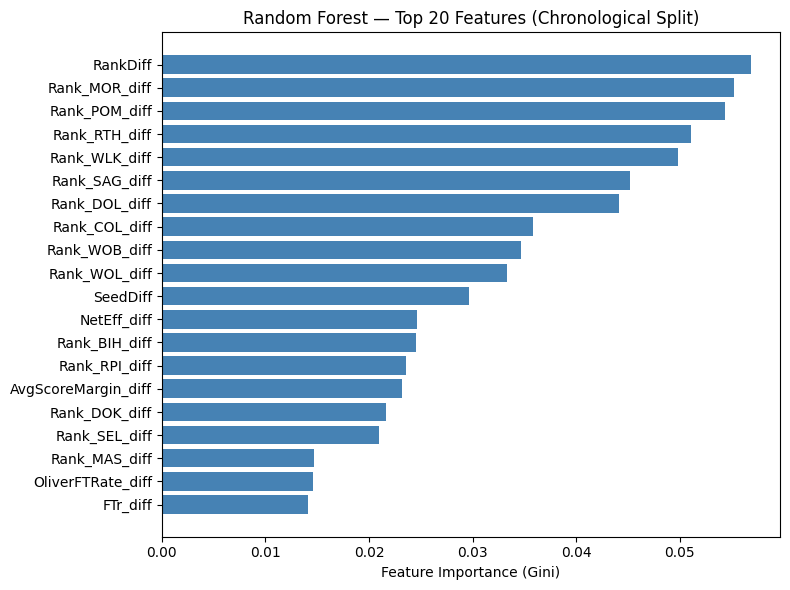

In [ ]:
# =============================================================================
# STEP 3: Tune & Train Random Forest
# =============================================================================
# RandomizedSearchCV tries random combinations of hyperparameters and picks the
# best one via cross-validation on the training set. We score on negative Brier
# score (our primary metric). This is much faster than exhaustive GridSearchCV
# when the search space is large.
#
# NOTE: Random Forests do NOT require feature scaling (no need for StandardScaler)
# because trees split on thresholds — the magnitude of features doesn't matter.
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# ---- Hyperparameter search space ----
param_dist = {
    'n_estimators':    [200, 400, 600, 800],       # number of trees in the forest
    'max_depth':       [8, 12, 16, 20, None],      # max tree depth (None = unlimited)
    'min_samples_leaf': [1, 2, 4, 8],              # min samples required at a leaf node
    'min_samples_split': [2, 5, 10],               # min samples to split an internal node
    'max_features':    ['sqrt', 'log2', 0.3],      # features considered at each split
}

# ---- Run hyperparameter search on chronological training set ----
print("Tuning Random Forest hyperparameters (this may take a minute)...")
rf_base = RandomForestClassifier(random_state=SEED)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=30,                    # try 30 random combinations
    cv=5,                         # 5-fold cross-validation
    scoring='neg_brier_score',    # optimize for Brier score (our primary metric)
    random_state=SEED,
    n_jobs=-1,                    # use all CPU cores
    verbose=0
)
search.fit(X_rf_chrono_train, y_rf_chrono_train)

# ---- Best hyperparameters ----
best_rf = search.best_estimator_
print(f"\nBest hyperparameters:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"Best CV Brier score: {-search.best_score_:.4f}")


# =============================================================================
# STEP 4: Evaluate on Both Splits
# =============================================================================

# ---- Chronological split ----
# Already trained on chrono training data above
y_pred_chrono = best_rf.predict_proba(X_rf_chrono_test)[:, 1]
evaluate_model(y_rf_chrono_test, y_pred_chrono, "Random Forest", "Chronological")

# ---- Random split ----
# Retrain on the random training set with the same best hyperparameters
rf_random = RandomForestClassifier(**search.best_params_, random_state=SEED)
rf_random.fit(X_rf_random_train, y_rf_random_train)
y_pred_random = rf_random.predict_proba(X_rf_random_test)[:, 1]
evaluate_model(y_rf_random_test, y_pred_random, "Random Forest", "Random")


# =============================================================================
# STEP 5: Feature Importance Analysis
# =============================================================================
# Random Forests measure feature importance by how much each feature reduces
# impurity (Gini) across all trees. Higher = more predictive.
# We show the top 20 features from the chronological model.

import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
feat_importance = pd.DataFrame({
    'Feature': RF_FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# ---- Print top 20 ----
print("\nTop 20 Most Important Features (Chronological RF):")
print("-" * 45)
for i, row in feat_importance.head(20).iterrows():
    bar = "█" * int(row['Importance'] * 200)  # simple text bar chart
    print(f"  {row['Feature']:<25s} {row['Importance']:.4f}  {bar}")

# ---- Plot top 20 ----
top20 = feat_importance.head(20).iloc[::-1]  # reverse for horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20['Feature'], top20['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Top 20 Features (Chronological Split)')
plt.tight_layout()
plt.show()

## Feedforward Neural Network (FFNN)

**Approach:** A fully connected neural network with 3 hidden layers, BatchNorm,
Dropout, and ReLU activations. Trained with binary cross-entropy loss and Adam
optimizer, with early stopping on the validation set's Brier score.

Unlike tree-based models (RF, XGBoost), neural networks **require feature scaling**
so that all inputs are on a similar range. We use `StandardScaler` to zero-mean
and unit-variance normalize all features before training.

**Architecture:** Input(32) → 64 → 32 → 16 → 1(sigmoid)

**Steps:**
1. Scale features with StandardScaler (fit on train only, transform all sets)
2. Define the FFNN architecture in PyTorch
3. Train with early stopping (patience on validation Brier score)
4. Evaluate on both chronological and random test sets

In [ ]:
# =============================================================================
# FFNN — Model Definition & Training Utilities
# =============================================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ---- Reproducibility ----
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ---- Device: use GPU if available (Colab often provides one) ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# =============================================================================
# Model Architecture
# =============================================================================
# A simple feedforward network:
#   Input -> [Linear -> BatchNorm -> ReLU -> Dropout] x3 -> Linear -> Sigmoid
#
# BatchNorm: stabilizes training by normalizing activations within each layer
# Dropout: randomly zeroes some neurons during training to prevent overfitting
# Sigmoid: squishes the final output to a probability between 0 and 1

class MarchMadnessFFNN(nn.Module):

    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))    # fully connected layer
            layers.append(nn.BatchNorm1d(h_dim))          # batch normalization
            layers.append(nn.ReLU())                      # activation function
            layers.append(nn.Dropout(dropout))            # regularization
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, 1))             # output layer (single probability)
        layers.append(nn.Sigmoid())                        # squish to [0, 1]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)   # squeeze to remove trailing dim -> shape (batch,)


# =============================================================================
# Training Function
# =============================================================================

def train_ffnn(model, X_train_t, y_train_t, X_val_t, y_val_t,
               epochs=300, lr=0.001, batch_size=64, patience=25):
    """
    Train the FFNN with early stopping.

    Parameters:
        model       : MarchMadnessFFNN instance (already on device)
        X_train_t   : training features (torch tensor on device)
        y_train_t   : training labels (torch tensor on device)
        X_val_t     : validation features (torch tensor on device)
        y_val_t     : validation labels (torch tensor on device)
        epochs      : maximum training epochs
        lr          : Adam learning rate
        batch_size  : mini-batch size
        patience    : early stopping patience (epochs without improvement)

    Returns:
        model with best weights restored, list of (train_loss, val_brier) per epoch
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()   # binary cross-entropy

    # DataLoader for mini-batch training
    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_val_brier = float('inf')
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(epochs):
        # ---- Training phase ----
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        epoch_loss /= len(train_ds)

        # ---- Validation phase ----
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_brier = ((val_pred - y_val_t) ** 2).mean().item()

        history.append((epoch_loss, val_brier))

        # ---- Early stopping check ----
        if val_brier < best_val_brier:
            best_val_brier = val_brier
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Print progress every 25 epochs
        if (epoch + 1) % 25 == 0 or patience_counter >= patience:
            print(f"  Epoch {epoch+1:>3d}/{epochs}  "
                  f"Train Loss: {epoch_loss:.4f}  "
                  f"Val Brier: {val_brier:.4f}  "
                  f"{'*** best' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    # Restore best weights
    model.load_state_dict(best_state)
    print(f"  Best validation Brier: {best_val_brier:.4f}")
    return model, history


# =============================================================================
# Helper: Scale features and convert to PyTorch tensors
# =============================================================================

def prepare_tensors(X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Scale features (fit on train only) and convert everything to tensors on device.
    Returns: scaler, and 6 tensors (X_train, y_train, X_val, y_val, X_test, y_test)
    """
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)        # fit + transform on train
    X_val_s   = scaler.transform(X_val)              # transform only (no fit!)
    X_test_s  = scaler.transform(X_test)             # transform only (no fit!)

    def to_tensor(arr):
        return torch.tensor(arr, dtype=torch.float32).to(device)

    return (scaler,
            to_tensor(X_train_s), to_tensor(y_train.values),
            to_tensor(X_val_s),   to_tensor(y_val.values),
            to_tensor(X_test_s),  to_tensor(y_test.values))


print("FFNN model and training utilities defined.")
print(f"Architecture: Input({len(FEATURE_COLS)}) -> 64 -> 32 -> 16 -> 1(sigmoid)")

Using device: cuda
FFNN model and training utilities defined.
Architecture: Input(32) -> 64 -> 32 -> 16 -> 1(sigmoid)


  Training FFNN — Chronological Split
  Epoch  25/300  Train Loss: 0.5385  Val Brier: 0.2320  
  Epoch  46/300  Train Loss: 0.4911  Val Brier: 0.2323  
  Early stopping at epoch 46 (no improvement for 25 epochs)
  Best validation Brier: 0.2246

  FFNN -- Chronological Split
  Brier Score : 0.1910   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5661   (lower=better)
  Accuracy    : 0.7313   (73.1%)
  AUC-ROC     : 0.7629   (higher=better; 0.5=random)

  Training FFNN — Random Split
  Epoch  25/300  Train Loss: 0.5367  Val Brier: 0.1824  *** best
  Epoch  50/300  Train Loss: 0.4947  Val Brier: 0.1904  
  Early stopping at epoch 50 (no improvement for 25 epochs)
  Best validation Brier: 0.1824

  FFNN -- Random Split
  Brier Score : 0.1935   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5596   (lower=better)
  Accuracy    : 0.7064   (70.6%)
  AUC-ROC     : 0.7703   (higher=better; 0.5=random)


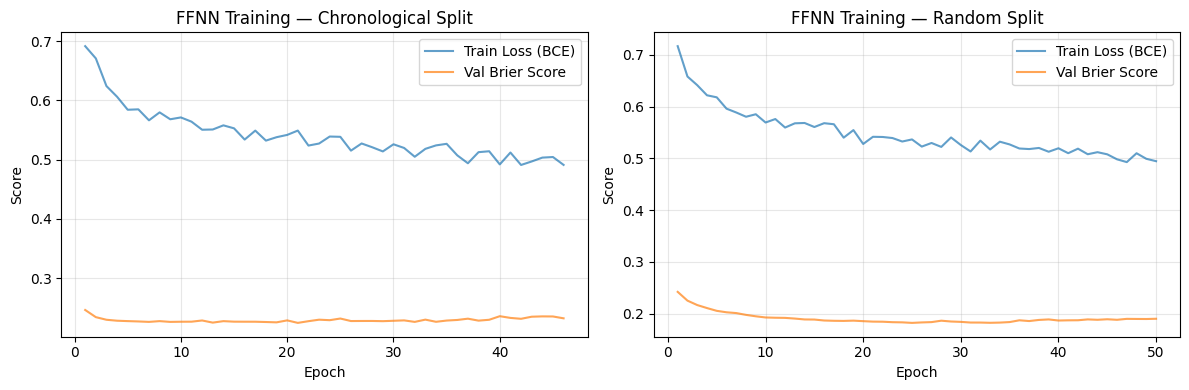

In [ ]:
# =============================================================================
# FFNN — Train & Evaluate on Both Splits
# =============================================================================

# ---- Chronological Split ----
print("=" * 55)
print("  Training FFNN — Chronological Split")
print("=" * 55)

# Scale features and convert to tensors
chrono_scaler, Xtr_c, ytr_c, Xv_c, yv_c, Xte_c, yte_c = prepare_tensors(
    X_chrono_train, y_chrono_train,
    X_chrono_val,   y_chrono_val,
    X_chrono_test,  y_chrono_test
)

# Create and train the model
ffnn_chrono = MarchMadnessFFNN(input_dim=len(FEATURE_COLS)).to(device)
ffnn_chrono, history_chrono = train_ffnn(ffnn_chrono, Xtr_c, ytr_c, Xv_c, yv_c)

# Predict on test set
ffnn_chrono.eval()
with torch.no_grad():
    y_pred_chrono = ffnn_chrono(Xte_c).cpu().numpy()

# Evaluate
evaluate_model(y_chrono_test, y_pred_chrono, "FFNN", "Chronological")


# ---- Random Split ----
print("\n" + "=" * 55)
print("  Training FFNN — Random Split")
print("=" * 55)

random_scaler, Xtr_r, ytr_r, Xv_r, yv_r, Xte_r, yte_r = prepare_tensors(
    X_random_train, y_random_train,
    X_random_val,   y_random_val,
    X_random_test,  y_random_test
)

ffnn_random = MarchMadnessFFNN(input_dim=len(FEATURE_COLS)).to(device)
ffnn_random, history_random = train_ffnn(ffnn_random, Xtr_r, ytr_r, Xv_r, yv_r)

ffnn_random.eval()
with torch.no_grad():
    y_pred_random = ffnn_random(Xte_r).cpu().numpy()

evaluate_model(y_random_test, y_pred_random, "FFNN", "Random")


# =============================================================================
# Training Curves — Visualize how training progressed
# =============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, history, title in [
    (axes[0], history_chrono, "Chronological Split"),
    (axes[1], history_random, "Random Split"),
]:
    losses, briers = zip(*history)
    epochs = range(1, len(history) + 1)
    ax.plot(epochs, losses, label='Train Loss (BCE)', alpha=0.7)
    ax.plot(epochs, briers, label='Val Brier Score', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title(f'FFNN Training — {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Long Short-Term Memory (LSTM)

**Approach:** Unlike the other three models that use **season-averaged** statistics,
the LSTM processes each team's **last 10 games as a sequence**. This lets it capture
momentum, hot streaks, slumps, and trajectory — patterns that season averages wash out.

**Architecture (Siamese LSTM):**
- Each team's last 10 games → shared LSTM encoder → hidden state (team embedding)
- Both teams' hidden states + static features (SeedDiff, RankDiff) → FC head → sigmoid
- The LSTM uses **shared weights** for both teams (Siamese design), so it learns one
  general "team trajectory encoder" rather than separate encoders.

```
TeamA: 10 games × 16 stats  ──→  LSTM  ──→  hidden_A  ──┐
                                   ↑ (shared weights)      ├──→ FC(32) → sigmoid → P(TeamA wins)
TeamB: 10 games × 16 stats  ──→  LSTM  ──→  hidden_B  ──┤
                                                           │
Static: [SeedDiff, RankDiff] ─────────────────────────────┘
```

**Per-game features (16):** Score, OppScore, FGM, FGA, FGM3, FGA3, FTM, FTA,
OR, DR, Ast, TO, Stl, Blk, PF, Win

**Steps:**
1. Build game-by-game sequences (last 10 regular season games per team per season)
2. Scale per-game features, pair up for each tournament matchup
3. Train Siamese LSTM with early stopping on validation Brier score
4. Evaluate on both chronological and random test sets

In [ ]:
# =============================================================================
# LSTM — Sequence Data Preparation & Model Definition
# =============================================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ---- Reproducibility ----
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# =============================================================================
# STEP 1: Build Game Sequences
# =============================================================================
# For each team in each season, we take their last K regular season games
# (sorted by DayNum) and extract per-game box score stats. This gives us a
# (K, num_features) matrix per team — the input to the LSTM.
#
# We use team_games from the Feature Engineering cell, which already has
# each game from one team's perspective with clean column names.

K = 10  # number of recent games to use as sequence length

# Per-game features the LSTM will see at each time step
SEQ_FEATURES = [
    'Score', 'OppScore',
    'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA',
    'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF',
    'Win'
]
seq_dim = len(SEQ_FEATURES)  # 16 features per game

# Static features appended alongside the LSTM hidden states
STATIC_FEATURES = ['SeedDiff', 'RankDiff']
static_dim = len(STATIC_FEATURES)

# ---- Sort games chronologically and grab last K per team per season ----
team_games_sorted = team_games.sort_values(['Season', 'TeamID', 'DayNum'])

# Group by (Season, TeamID) and take the last K games
# This gives us the most recent regular season games before the tournament
sequences = {}   # key: (season, team_id) -> np.array of shape (K, seq_dim)

for (season, team_id), group in team_games_sorted.groupby(['Season', 'TeamID']):
    game_matrix = group[SEQ_FEATURES].values  # shape: (num_games, 16)

    if len(game_matrix) >= K:
        # Take the last K games
        sequences[(season, team_id)] = game_matrix[-K:]
    else:
        # Rare: fewer than K games — pad the front with zeros
        pad = np.zeros((K - len(game_matrix), seq_dim))
        sequences[(season, team_id)] = np.vstack([pad, game_matrix])

print(f"Built sequences for {len(sequences):,} (season, team) pairs")
print(f"Each sequence: {K} games x {seq_dim} features")


# ---- Fit a scaler on training sequences only ----
# Stack all training-era sequences to fit the scaler, then transform everything.
# This prevents data leakage from future seasons into the scaler.
train_seqs = []
for (season, team_id), seq in sequences.items():
    if season in TRAIN_SEASONS:
        train_seqs.append(seq)

# Reshape to (total_games, features) for fitting
train_flat = np.vstack(train_seqs)
seq_scaler = StandardScaler().fit(train_flat)

# Scale all sequences
for key in sequences:
    sequences[key] = seq_scaler.transform(sequences[key])

print(f"Scaler fit on {len(train_flat):,} training game rows")


# =============================================================================
# STEP 2: Build Matchup Dataset
# =============================================================================
# For each tournament game, pair up both teams' sequences + static features.

def build_lstm_dataset(matchups_df, sequences_dict):
    """
    Build arrays for LSTM training/evaluation from a matchup DataFrame.

    Returns:
        seq_a:   np.array (N, K, seq_dim) — TeamA's game sequences
        seq_b:   np.array (N, K, seq_dim) — TeamB's game sequences
        static:  np.array (N, static_dim) — static features (SeedDiff, RankDiff)
        labels:  np.array (N,) — 0 or 1
    """
    seq_a_list, seq_b_list, static_list, label_list = [], [], [], []

    for _, row in matchups_df.iterrows():
        s, ta, tb = int(row['Season']), int(row['TeamA']), int(row['TeamB'])

        # Look up sequences for both teams
        if (s, ta) not in sequences_dict or (s, tb) not in sequences_dict:
            continue

        seq_a_list.append(sequences_dict[(s, ta)])
        seq_b_list.append(sequences_dict[(s, tb)])
        static_list.append([row[f] for f in STATIC_FEATURES])
        label_list.append(row['Label'])

    return (np.array(seq_a_list), np.array(seq_b_list),
            np.array(static_list), np.array(label_list))


# ---- Build datasets for both splits ----
# Chronological
sa_ctr, sb_ctr, st_ctr, y_ctr = build_lstm_dataset(matchups_chrono_train, sequences)
sa_cv,  sb_cv,  st_cv,  y_cv  = build_lstm_dataset(matchups_chrono_val,   sequences)
sa_cte, sb_cte, st_cte, y_cte = build_lstm_dataset(matchups_chrono_test,  sequences)

# Random
sa_rtr, sb_rtr, st_rtr, y_rtr = build_lstm_dataset(matchups_random_train, sequences)
sa_rv,  sb_rv,  st_rv,  y_rv  = build_lstm_dataset(matchups_random_val,   sequences)
sa_rte, sb_rte, st_rte, y_rte = build_lstm_dataset(matchups_random_test,  sequences)

print(f"\nChrono — Train: {len(y_ctr)}, Val: {len(y_cv)}, Test: {len(y_cte)}")
print(f"Random — Train: {len(y_rtr)}, Val: {len(y_rv)}, Test: {len(y_rte)}")


# =============================================================================
# STEP 3: PyTorch Dataset & Model
# =============================================================================

class MatchupSequenceDataset(Dataset):
    """PyTorch Dataset for LSTM matchup data."""

    def __init__(self, seq_a, seq_b, static, labels):
        self.seq_a  = torch.tensor(seq_a,  dtype=torch.float32)
        self.seq_b  = torch.tensor(seq_b,  dtype=torch.float32)
        self.static = torch.tensor(static, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.seq_a[idx], self.seq_b[idx], self.static[idx], self.labels[idx]


class MarchMadnessLSTM(nn.Module):
    """
    Siamese LSTM: both teams share the same LSTM encoder.
    Their hidden states are concatenated with static features and
    fed through a small FC head to predict win probability.
    """

    def __init__(self, seq_feature_dim, static_dim, hidden_dim=64,
                 num_layers=2, dropout=0.3):
        super().__init__()

        # Shared LSTM encoder (processes one team's game sequence)
        self.lstm = nn.LSTM(
            input_size=seq_feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # FC head: combines both teams' encodings + static features
        fc_input_dim = hidden_dim * 2 + static_dim
        self.fc = nn.Sequential(
            nn.Linear(fc_input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, seq_a, seq_b, static):
        # Encode TeamA's sequence
        _, (h_a, _) = self.lstm(seq_a)   # h_a shape: (num_layers, batch, hidden)
        # Encode TeamB's sequence (same LSTM weights)
        _, (h_b, _) = self.lstm(seq_b)

        # Take the final layer's hidden state
        h_a = h_a[-1]   # (batch, hidden_dim)
        h_b = h_b[-1]

        # Concatenate both encodings + static features -> predict
        combined = torch.cat([h_a, h_b, static], dim=1)
        return self.fc(combined).squeeze(-1)


print(f"LSTM model defined.")
print(f"  Sequence input: {K} timesteps x {seq_dim} features per team")
print(f"  Static input: {static_dim} features (SeedDiff, RankDiff)")
print(f"  Architecture: LSTM(64, 2 layers) -> FC(32) -> sigmoid")

Using device: cuda
Built sequences for 8,346 (season, team) pairs
Each sequence: 10 games x 16 features
Scaler fit on 61,870 training game rows

Chrono — Train: 1115, Val: 133, Test: 201
Random — Train: 1013, Val: 218, Test: 218
LSTM model defined.
  Sequence input: 10 timesteps x 16 features per team
  Static input: 2 features (SeedDiff, RankDiff)
  Architecture: LSTM(64, 2 layers) -> FC(32) -> sigmoid


  Training LSTM — Chronological Split
  Epoch  25/300  Train Loss: 0.3383  Val Brier: 0.2748  
  Epoch  32/300  Train Loss: 0.2553  Val Brier: 0.2966  
  Early stopping at epoch 32 (no improvement for 30 epochs)
  Best validation Brier: 0.2146

  LSTM -- Chronological Split
  Brier Score : 0.1953   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5762   (lower=better)
  Accuracy    : 0.7114   (71.1%)
  AUC-ROC     : 0.7826   (higher=better; 0.5=random)

  Training LSTM — Random Split
  Epoch  25/300  Train Loss: 0.3230  Val Brier: 0.2596  
  Epoch  35/300  Train Loss: 0.1948  Val Brier: 0.2753  
  Early stopping at epoch 35 (no improvement for 30 epochs)
  Best validation Brier: 0.1883

  LSTM -- Random Split
  Brier Score : 0.1898   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5560   (lower=better)
  Accuracy    : 0.6927   (69.3%)
  AUC-ROC     : 0.7807   (higher=better; 0.5=random)


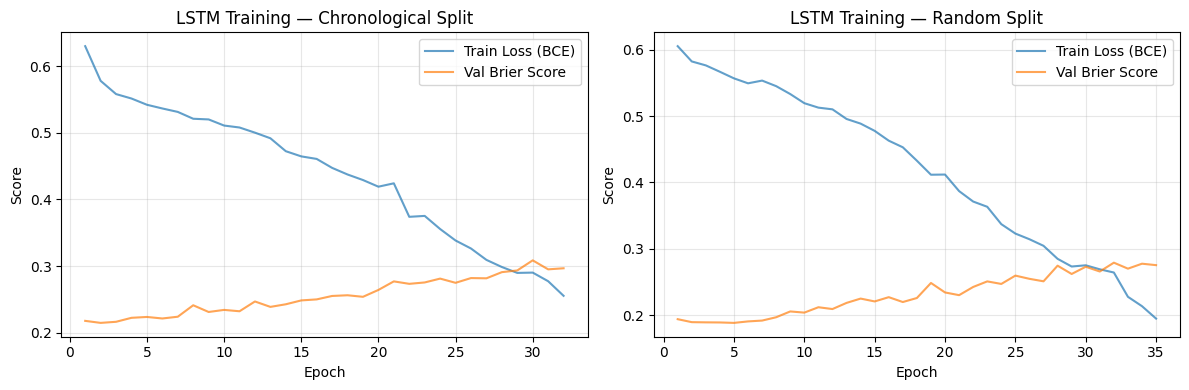

In [ ]:
# =============================================================================
# LSTM — Train & Evaluate on Both Splits
# =============================================================================

def train_lstm(model, train_ds, val_ds, epochs=300, lr=0.001,
               batch_size=64, patience=30):
    """
    Train the LSTM with early stopping on validation Brier score.

    Parameters:
        model     : MarchMadnessLSTM on device
        train_ds  : MatchupSequenceDataset (training)
        val_ds    : MatchupSequenceDataset (validation)
        epochs    : max training epochs
        lr        : learning rate for Adam
        batch_size: mini-batch size
        patience  : early stopping patience

    Returns:
        model with best weights, training history
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # Pre-move validation data to device
    val_sa = val_ds.seq_a.to(device)
    val_sb = val_ds.seq_b.to(device)
    val_st = val_ds.static.to(device)
    val_y  = val_ds.labels.to(device)

    best_val_brier = float('inf')
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        epoch_loss = 0.0
        for sa, sb, st, y in train_loader:
            sa, sb, st, y = sa.to(device), sb.to(device), st.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(sa, sb, st)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y)
        epoch_loss /= len(train_ds)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_pred = model(val_sa, val_sb, val_st)
            val_brier = ((val_pred - val_y) ** 2).mean().item()

        history.append((epoch_loss, val_brier))

        # ---- Early stopping ----
        if val_brier < best_val_brier:
            best_val_brier = val_brier
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 25 == 0 or patience_counter >= patience:
            print(f"  Epoch {epoch+1:>3d}/{epochs}  "
                  f"Train Loss: {epoch_loss:.4f}  "
                  f"Val Brier: {val_brier:.4f}  "
                  f"{'*** best' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    model.load_state_dict(best_state)
    print(f"  Best validation Brier: {best_val_brier:.4f}")
    return model, history


def predict_lstm(model, dataset):
    """Get predictions from a trained LSTM on a dataset."""
    model.eval()
    with torch.no_grad():
        sa = dataset.seq_a.to(device)
        sb = dataset.seq_b.to(device)
        st = dataset.static.to(device)
        return model(sa, sb, st).cpu().numpy()


# ---- Build PyTorch datasets ----
ds_ctr = MatchupSequenceDataset(sa_ctr, sb_ctr, st_ctr, y_ctr)
ds_cv  = MatchupSequenceDataset(sa_cv,  sb_cv,  st_cv,  y_cv)
ds_cte = MatchupSequenceDataset(sa_cte, sb_cte, st_cte, y_cte)

ds_rtr = MatchupSequenceDataset(sa_rtr, sb_rtr, st_rtr, y_rtr)
ds_rv  = MatchupSequenceDataset(sa_rv,  sb_rv,  st_rv,  y_rv)
ds_rte = MatchupSequenceDataset(sa_rte, sb_rte, st_rte, y_rte)


# =============================================================================
# Train & Evaluate — Chronological Split
# =============================================================================
print("=" * 55)
print("  Training LSTM — Chronological Split")
print("=" * 55)

lstm_chrono = MarchMadnessLSTM(
    seq_feature_dim=seq_dim, static_dim=static_dim
).to(device)

lstm_chrono, hist_chrono = train_lstm(lstm_chrono, ds_ctr, ds_cv)

y_pred_chrono = predict_lstm(lstm_chrono, ds_cte)
evaluate_model(y_cte, y_pred_chrono, "LSTM", "Chronological")


# =============================================================================
# Train & Evaluate — Random Split
# =============================================================================
print("\n" + "=" * 55)
print("  Training LSTM — Random Split")
print("=" * 55)

lstm_random = MarchMadnessLSTM(
    seq_feature_dim=seq_dim, static_dim=static_dim
).to(device)

lstm_random, hist_random = train_lstm(lstm_random, ds_rtr, ds_rv)

y_pred_random = predict_lstm(lstm_random, ds_rte)
evaluate_model(y_rte, y_pred_random, "LSTM", "Random")


# =============================================================================
# Training Curves
# =============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, history, title in [
    (axes[0], hist_chrono, "Chronological Split"),
    (axes[1], hist_random, "Random Split"),
]:
    losses, briers = zip(*history)
    epochs_range = range(1, len(history) + 1)
    ax.plot(epochs_range, losses, label='Train Loss (BCE)', alpha=0.7)
    ax.plot(epochs_range, briers, label='Val Brier Score', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title(f'LSTM Training — {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Jackson's Section

Reliable ranking systems (18+ of 23 seasons): 19
Systems: ['AP', 'BIH', 'COL', 'DOK', 'DOL', 'DUN', 'MAS', 'MOR', 'PGH', 'POM', 'RPI', 'RTH', 'SAG', 'SEL', 'USA', 'WIL', 'WLK', 'WOB', 'WOL']

XGBoost feature set: 51 total features
  Shared features:         32
  Ranking system features: 19

Chrono split — Train: 1115, Val: 133, Test: 201
Random split — Train: 1013, Val: 218, Test: 218

Tuning XGBoost hyperparameters (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:25:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best hyperparameters:
  subsample: 0.6
  reg_lambda: 1.0
  reg_alpha: 0.5
  n_estimators: 200
  min_child_weight: 5
  max_depth: 3
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 1.0
Best CV Brier score: 0.1894

  XGBoost -- Chronological Split
  Brier Score : 0.1912   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5662   (lower=better)
  Accuracy    : 0.7114   (71.1%)
  AUC-ROC     : 0.7788   (higher=better; 0.5=random)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:25:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGBoost -- Random Split
  Brier Score : 0.1924   (lower=better; 0.25=coin flip)
  Log Loss    : 0.5665   (lower=better)
  Accuracy    : 0.7156   (71.6%)
  AUC-ROC     : 0.7785   (higher=better; 0.5=random)

Top 20 Most Important Features (XGBoost, gain-based, Chronological):
--------------------------------------------------
  Rank_POM_diff                41.69  ██████████████████████████████
  Rank_RTH_diff                32.34  ███████████████████████
  Rank_WOL_diff                30.02  █████████████████████
  Rank_MOR_diff                27.59  ███████████████████
  Rank_COL_diff                22.78  ████████████████
  RankDiff                     21.82  ███████████████
  Rank_WLK_diff                19.66  ██████████████
  Rank_SAG_diff                18.90  █████████████
  Rank_DOL_diff                16.83  ████████████
  Rank_RPI_diff                12.11  ████████
  SeedDiff                      9.14  ██████
  AvgScoreMargin_diff           9.01  ██████
  WinPct_diff      

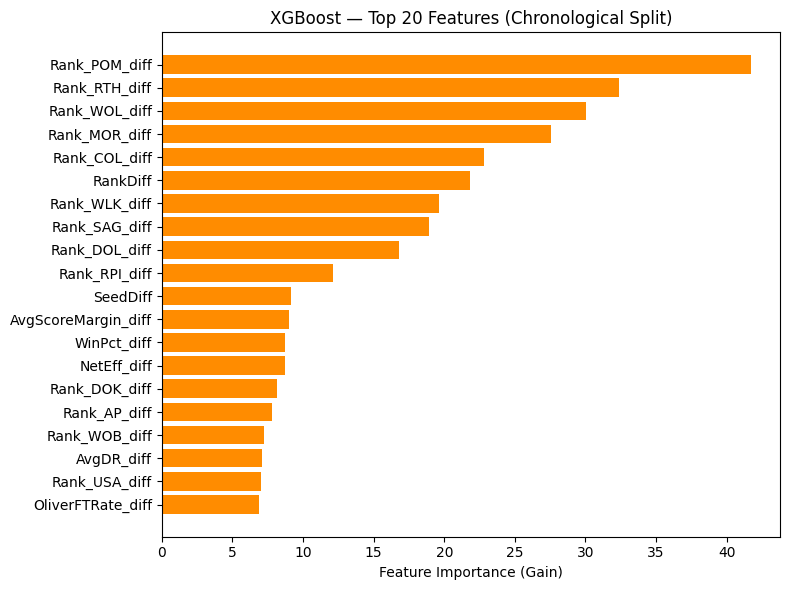

In [ ]:
# =============================================================================
# XGBOOST MODEL
# =============================================================================
# Approach: Use the 32 shared features + individual Massey Ordinal ranking
# system differentials (Pomeroy, Sagarin, RPI, etc.), built independently
# of Nick's Random Forest section. XGBoost iteratively corrects residuals
# via gradient boosting, making it well-suited for structured tabular data.
# We tune learning rate, tree depth, subsampling, and regularization
# coefficients (lambda, alpha) via RandomizedSearchCV.
#
# Steps:
#   1. Build extended feature matrix from shared features + ranking diffs
#   2. Split data (chronological and random, same boundaries as Standard Import)
#   3. Tune hyperparameters via RandomizedSearchCV
#   4. Evaluate on both test sets using evaluate_model()
#   5. Inspect feature importances (gain-based)
# =============================================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
import matplotlib.pyplot as plt

# =============================================================================
# STEP 1: Build Extended Feature Matrix
# =============================================================================
# Start from the shared tourney_matchups DataFrame, then append individual
# ranking system differentials from the Massey Ordinals (day 133 = final
# pre-tournament rankings). Each system gets its own diff column so XGBoost
# can learn which ranking methodologies are most predictive.

# ---- Get final pre-tournament rankings (day 133) ----
xgb_day133 = ordinals[ordinals['RankingDayNum'] == 133].copy()

# ---- Keep only reliable systems (present in 80%+ of seasons) ----
xgb_system_coverage = xgb_day133.groupby('SystemName')['Season'].nunique()
xgb_n_seasons = xgb_day133['Season'].nunique()
xgb_min_seasons = int(xgb_n_seasons * 0.8)
xgb_reliable_systems = sorted(
    xgb_system_coverage[xgb_system_coverage >= xgb_min_seasons].index.tolist()
)

print(f"Reliable ranking systems ({xgb_min_seasons}+ of {xgb_n_seasons} seasons): "
      f"{len(xgb_reliable_systems)}")
print(f"Systems: {xgb_reliable_systems}")

# ---- Pivot to wide format: one column per system per team-season ----
xgb_rankings_wide = (
    xgb_day133[xgb_day133['SystemName'].isin(xgb_reliable_systems)]
    .pivot_table(index=['Season', 'TeamID'],
                 columns='SystemName',
                 values='OrdinalRank')
    .reset_index()
)
xgb_rankings_wide.columns.name = None

# ---- Merge TeamA rankings ----
xgb_matchups = tourney_matchups.merge(
    xgb_rankings_wide,
    left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'],
    how='left'
).drop(columns=['TeamID'], errors='ignore')
xgb_matchups = xgb_matchups.rename(
    columns={sys: f'{sys}_A' for sys in xgb_reliable_systems}
)

# ---- Merge TeamB rankings ----
xgb_matchups = xgb_matchups.merge(
    xgb_rankings_wide,
    left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'],
    how='left'
).drop(columns=['TeamID'], errors='ignore')
xgb_matchups = xgb_matchups.rename(
    columns={sys: f'{sys}_B' for sys in xgb_reliable_systems}
)

# ---- Compute per-system ranking differentials ----
xgb_rank_sys_cols = []
for sys in xgb_reliable_systems:
    col = f'Rank_{sys}_diff'
    xgb_matchups[col] = xgb_matchups[f'{sys}_A'] - xgb_matchups[f'{sys}_B']
    xgb_rank_sys_cols.append(col)

# Drop raw _A / _B columns
xgb_matchups = xgb_matchups.drop(
    columns=[f'{sys}_A' for sys in xgb_reliable_systems] +
             [f'{sys}_B' for sys in xgb_reliable_systems]
)
xgb_matchups[xgb_rank_sys_cols] = xgb_matchups[xgb_rank_sys_cols].fillna(0)

# ---- Full XGBoost feature set ----
XGB_FEATURE_COLS = FEATURE_COLS + xgb_rank_sys_cols
print(f"\nXGBoost feature set: {len(XGB_FEATURE_COLS)} total features")
print(f"  Shared features:         {len(FEATURE_COLS)}")
print(f"  Ranking system features: {len(xgb_rank_sys_cols)}")


# =============================================================================
# STEP 2: Split Data
# =============================================================================

# ---- Chronological split ----
xgb_chrono_train = xgb_matchups[xgb_matchups['Season'].isin(TRAIN_SEASONS)].reset_index(drop=True)
xgb_chrono_val   = xgb_matchups[xgb_matchups['Season'].isin(VAL_SEASONS)].reset_index(drop=True)
xgb_chrono_test  = xgb_matchups[xgb_matchups['Season'].isin(TEST_SEASONS)].reset_index(drop=True)

X_xgb_chrono_train = xgb_chrono_train[XGB_FEATURE_COLS]
y_xgb_chrono_train = xgb_chrono_train['Label']
X_xgb_chrono_val   = xgb_chrono_val[XGB_FEATURE_COLS]
y_xgb_chrono_val   = xgb_chrono_val['Label']
X_xgb_chrono_test  = xgb_chrono_test[XGB_FEATURE_COLS]
y_xgb_chrono_test  = xgb_chrono_test['Label']

# ---- Random split (70/15/15, SEED=573) ----
xgb_random_trainval, xgb_random_test = train_test_split(
    xgb_matchups, test_size=0.15, random_state=SEED, stratify=xgb_matchups['Label']
)
xgb_random_train, xgb_random_val = train_test_split(
    xgb_random_trainval, test_size=(15/85), random_state=SEED,
    stratify=xgb_random_trainval['Label']
)

X_xgb_random_train = xgb_random_train[XGB_FEATURE_COLS].reset_index(drop=True)
y_xgb_random_train = xgb_random_train['Label'].reset_index(drop=True)
X_xgb_random_val   = xgb_random_val[XGB_FEATURE_COLS].reset_index(drop=True)
y_xgb_random_val   = xgb_random_val['Label'].reset_index(drop=True)
X_xgb_random_test  = xgb_random_test[XGB_FEATURE_COLS].reset_index(drop=True)
y_xgb_random_test  = xgb_random_test['Label'].reset_index(drop=True)

print(f"\nChrono split — Train: {len(xgb_chrono_train)}, "
      f"Val: {len(xgb_chrono_val)}, Test: {len(xgb_chrono_test)}")
print(f"Random split — Train: {len(xgb_random_train)}, "
      f"Val: {len(xgb_random_val)}, Test: {len(xgb_random_test)}")


# =============================================================================
# STEP 3: Tune XGBoost Hyperparameters
# =============================================================================
# Tuning targets the parameters called out in the proposal:
#   - learning_rate      : shrinks each tree's contribution (combats overfitting)
#   - max_depth          : controls tree complexity
#   - subsample          : row subsampling per tree (like RF's bootstrap)
#   - colsample_bytree   : feature subsampling per tree
#   - reg_alpha (lambda) : L1 regularization on leaf weights
#   - reg_lambda (alpha) : L2 regularization on leaf weights
#   - gamma              : min loss reduction required to make a split
#   - min_child_weight   : min sum of instance weight in a child node

param_dist_xgb = {
    'n_estimators':     [200, 400, 600, 800],
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0, 10.0],
    'gamma':            [0, 0.1, 0.3, 0.5],
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

print("\nTuning XGBoost hyperparameters (this may take a minute)...")

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=60,
    cv=5,
    scoring='neg_brier_score',
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)
xgb_search.fit(X_xgb_chrono_train, y_xgb_chrono_train)

best_xgb = xgb_search.best_estimator_

print(f"\nBest hyperparameters:")
for param, val in xgb_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"Best CV Brier score: {-xgb_search.best_score_:.4f}")


# =============================================================================
# STEP 4: Evaluate on Both Splits
# =============================================================================

# ---- Chronological split ----
y_pred_xgb_chrono = best_xgb.predict_proba(X_xgb_chrono_test)[:, 1]
evaluate_model(y_xgb_chrono_test, y_pred_xgb_chrono, "XGBoost", "Chronological")

# ---- Random split ----
best_xgb_random = XGBClassifier(
    **xgb_search.best_params_,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)
best_xgb_random.fit(X_xgb_random_train, y_xgb_random_train)
y_pred_xgb_random = best_xgb_random.predict_proba(X_xgb_random_test)[:, 1]
evaluate_model(y_xgb_random_test, y_pred_xgb_random, "XGBoost", "Random")


# =============================================================================
# STEP 5: Feature Importance Analysis (Gain-Based)
# =============================================================================
# 'gain' = average loss reduction per split using that feature.
# More informative than 'weight' (split count) for comparing features
# of different scales.

importances_xgb = best_xgb.get_booster().get_score(importance_type='gain')

feat_importance_xgb = pd.DataFrame({
    'Feature':    XGB_FEATURE_COLS,
    'Importance': [importances_xgb.get(f, 0.0) for f in XGB_FEATURE_COLS]
}).sort_values('Importance', ascending=False)

# ---- Print top 20 ----
print("\nTop 20 Most Important Features (XGBoost, gain-based, Chronological):")
print("-" * 50)
max_imp = feat_importance_xgb['Importance'].max()
for _, row in feat_importance_xgb.head(20).iterrows():
    bar = "█" * int(row['Importance'] / max_imp * 30)
    print(f"  {row['Feature']:<25s} {row['Importance']:8.2f}  {bar}")

# ---- Plot top 20 ----
top20_xgb = feat_importance_xgb.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_xgb['Feature'], top20_xgb['Importance'], color='darkorange')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Top 20 Features (Chronological Split)')
plt.tight_layout()
plt.show()

# John's Section

## Notes

- **Scaling is applied here** unlike the tree models — the scaler is fit only on training data and then applied to val and test separately for each split, so there's no leakage.
- **Early stopping** on validation Brier score prevents overfitting without needing a fixed epoch count.
- **The architecture sweep** runs on the val set (not test) to pick the best design, then the final model is trained fresh with that architecture before evaluating on test — same principle as the `RandomizedSearchCV` approach in the other two models.
- **Permutation importance** is used instead of gradient-based saliency because it's model-agnostic and directly measures impact on Brier score, making it directly comparable to the RF and XGBoost importance plots.

Reliable ranking systems (18+ of 23 seasons): 19
Systems: ['AP', 'BIH', 'COL', 'DOK', 'DOL', 'DUN', 'MAS', 'MOR', 'PGH', 'POM', 'RPI', 'RTH', 'SAG', 'SEL', 'USA', 'WIL', 'WLK', 'WOB', 'WOL']

FFNN feature set: 51 total features
  Shared features:         32
  Ranking system features: 19

Chrono split — Train: 1115, Val: 133, Test: 201
Random split — Train: 1013, Val: 218, Test: 218
Sweeping FFNN architectures on chronological validation set...

  Architecture                   Dropout    Val Brier
  -------------------------------------------------------
  [128, 64]                      0.3        0.2180  ← best
  [256, 128]                     0.3        0.2207
  [256, 128, 64]                 0.3        0.2139  ← best
  [256, 128, 64]                 0.4        0.2176
  [512, 256, 128]                0.3        0.2221
  [512, 256, 128, 64]            0.3        0.2145
  [512, 256, 128, 64]            0.4        0.2150

Best architecture: [256, 128, 64]  dropout=0.3  val Brier=0.2139


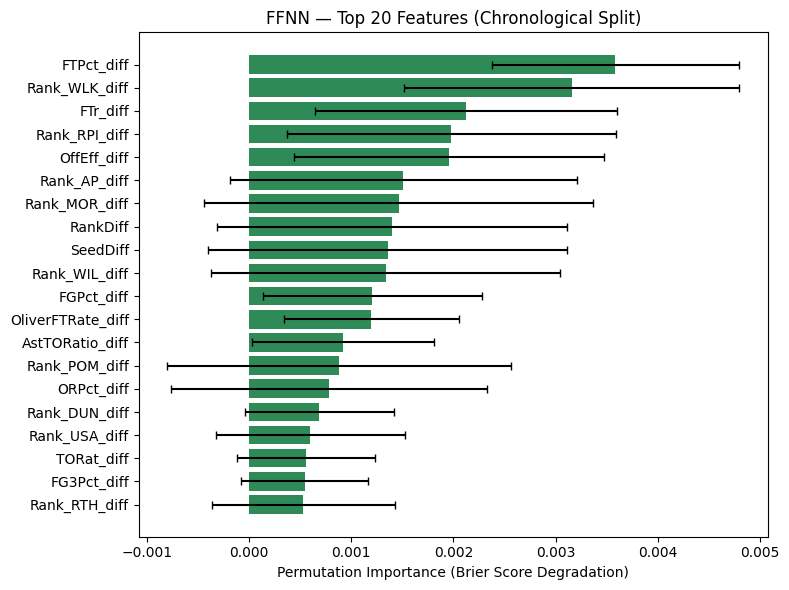

In [ ]:
# =============================================================================
# FEEDFORWARD NEURAL NETWORK (FFNN)
# =============================================================================
# Approach: Use the 32 shared features + individual Massey Ordinal ranking
# system differentials, built independently of all other sections.
# Architecture: 2-4 hidden layers, ReLU activations, batch normalization,
# and dropout regularization. Trained with binary cross-entropy loss via
# Adam optimizer. We manually sweep architectures on the validation set
# to select the best model.
#
# Steps:
#   1. Build extended feature matrix from shared features + ranking diffs
#   2. Split data and scale features (FFNNs require scaling, unlike trees)
#   3. Define the FFNN architecture in PyTorch
#   4. Train with architecture sweep on validation set
#   5. Evaluate best model on both test sets using evaluate_model()
#   6. Inspect learned feature importances via permutation importance
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Set torch seed for reproducibility
torch.manual_seed(SEED)

# =============================================================================
# STEP 1: Build Extended Feature Matrix (independent of RF and XGBoost)
# =============================================================================

# ---- Get final pre-tournament rankings (day 133) ----
ffnn_day133 = ordinals[ordinals['RankingDayNum'] == 133].copy()

# ---- Keep only reliable systems (present in 80%+ of seasons) ----
ffnn_system_coverage = ffnn_day133.groupby('SystemName')['Season'].nunique()
ffnn_n_seasons = ffnn_day133['Season'].nunique()
ffnn_min_seasons = int(ffnn_n_seasons * 0.8)
ffnn_reliable_systems = sorted(
    ffnn_system_coverage[ffnn_system_coverage >= ffnn_min_seasons].index.tolist()
)

print(f"Reliable ranking systems ({ffnn_min_seasons}+ of {ffnn_n_seasons} seasons): "
      f"{len(ffnn_reliable_systems)}")
print(f"Systems: {ffnn_reliable_systems}")

# ---- Pivot to wide format: one column per system per team-season ----
ffnn_rankings_wide = (
    ffnn_day133[ffnn_day133['SystemName'].isin(ffnn_reliable_systems)]
    .pivot_table(index=['Season', 'TeamID'],
                 columns='SystemName',
                 values='OrdinalRank')
    .reset_index()
)
ffnn_rankings_wide.columns.name = None

# ---- Merge TeamA rankings ----
ffnn_matchups = tourney_matchups.merge(
    ffnn_rankings_wide,
    left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'],
    how='left'
).drop(columns=['TeamID'], errors='ignore')
ffnn_matchups = ffnn_matchups.rename(
    columns={sys: f'{sys}_A' for sys in ffnn_reliable_systems}
)

# ---- Merge TeamB rankings ----
ffnn_matchups = ffnn_matchups.merge(
    ffnn_rankings_wide,
    left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'],
    how='left'
).drop(columns=['TeamID'], errors='ignore')
ffnn_matchups = ffnn_matchups.rename(
    columns={sys: f'{sys}_B' for sys in ffnn_reliable_systems}
)

# ---- Compute per-system ranking differentials ----
ffnn_rank_sys_cols = []
for sys in ffnn_reliable_systems:
    col = f'Rank_{sys}_diff'
    ffnn_matchups[col] = ffnn_matchups[f'{sys}_A'] - ffnn_matchups[f'{sys}_B']
    ffnn_rank_sys_cols.append(col)

# Drop raw _A / _B columns
ffnn_matchups = ffnn_matchups.drop(
    columns=[f'{sys}_A' for sys in ffnn_reliable_systems] +
             [f'{sys}_B' for sys in ffnn_reliable_systems]
)
ffnn_matchups[ffnn_rank_sys_cols] = ffnn_matchups[ffnn_rank_sys_cols].fillna(0)

# ---- Full FFNN feature set ----
FFNN_FEATURE_COLS = FEATURE_COLS + ffnn_rank_sys_cols
print(f"\nFFNN feature set: {len(FFNN_FEATURE_COLS)} total features")
print(f"  Shared features:         {len(FEATURE_COLS)}")
print(f"  Ranking system features: {len(ffnn_rank_sys_cols)}")


# =============================================================================
# STEP 2: Split Data and Scale Features
# =============================================================================
# Unlike tree-based models, FFNNs are sensitive to feature scale.
# We fit the scaler ONLY on training data, then apply to val and test
# to avoid data leakage.

# ---- Chronological split ----
ffnn_chrono_train = ffnn_matchups[ffnn_matchups['Season'].isin(TRAIN_SEASONS)].reset_index(drop=True)
ffnn_chrono_val   = ffnn_matchups[ffnn_matchups['Season'].isin(VAL_SEASONS)].reset_index(drop=True)
ffnn_chrono_test  = ffnn_matchups[ffnn_matchups['Season'].isin(TEST_SEASONS)].reset_index(drop=True)

# ---- Random split (70/15/15, SEED=573) ----
ffnn_random_trainval, ffnn_random_test = train_test_split(
    ffnn_matchups, test_size=0.15, random_state=SEED, stratify=ffnn_matchups['Label']
)
ffnn_random_train, ffnn_random_val = train_test_split(
    ffnn_random_trainval, test_size=(15/85), random_state=SEED,
    stratify=ffnn_random_trainval['Label']
)
ffnn_random_train = ffnn_random_train.reset_index(drop=True)
ffnn_random_val   = ffnn_random_val.reset_index(drop=True)
ffnn_random_test  = ffnn_random_test.reset_index(drop=True)

print(f"\nChrono split — Train: {len(ffnn_chrono_train)}, "
      f"Val: {len(ffnn_chrono_val)}, Test: {len(ffnn_chrono_test)}")
print(f"Random split — Train: {len(ffnn_random_train)}, "
      f"Val: {len(ffnn_random_val)}, Test: {len(ffnn_random_test)}")

# ---- Scale features (fit on train only) ----
# Chronological scaler
chrono_scaler = StandardScaler()
X_ffnn_chrono_train = chrono_scaler.fit_transform(ffnn_chrono_train[FFNN_FEATURE_COLS])
X_ffnn_chrono_val   = chrono_scaler.transform(ffnn_chrono_val[FFNN_FEATURE_COLS])
X_ffnn_chrono_test  = chrono_scaler.transform(ffnn_chrono_test[FFNN_FEATURE_COLS])
y_ffnn_chrono_train = ffnn_chrono_train['Label'].values
y_ffnn_chrono_val   = ffnn_chrono_val['Label'].values
y_ffnn_chrono_test  = ffnn_chrono_test['Label'].values

# Random scaler
random_scaler = StandardScaler()
X_ffnn_random_train = random_scaler.fit_transform(ffnn_random_train[FFNN_FEATURE_COLS])
X_ffnn_random_val   = random_scaler.transform(ffnn_random_val[FFNN_FEATURE_COLS])
X_ffnn_random_test  = random_scaler.transform(ffnn_random_test[FFNN_FEATURE_COLS])
y_ffnn_random_train = ffnn_random_train['Label'].values
y_ffnn_random_val   = ffnn_random_val['Label'].values
y_ffnn_random_test  = ffnn_random_test['Label'].values


# =============================================================================
# STEP 3: Define FFNN Architecture
# =============================================================================

class FFNN(nn.Module):
    """
    Fully connected network for binary classification.
    Architecture: Input -> [Linear -> BN -> ReLU -> Dropout] x N -> Linear -> Sigmoid
    hidden_dims : list of ints, one per hidden layer (e.g. [128, 64])
    dropout_rate: dropout probability applied after each hidden layer
    """
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.3):
        super(FFNN, self).__init__()

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
            ]
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, 1))   # output logit
        layers.append(nn.Sigmoid())              # squash to probability

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def make_tensors(X, y):
    """Convert numpy arrays to float tensors."""
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32))


def train_ffnn(model, X_train, y_train, X_val, y_val,
               lr=1e-3, epochs=150, batch_size=64, patience=20):
    """
    Train the FFNN with early stopping on validation loss.
    Returns the best validation Brier score achieved.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()

    X_tr_t, y_tr_t = make_tensors(X_train, y_train)
    X_val_t, y_val_t = make_tensors(X_val, y_val)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=batch_size, shuffle=True)

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t).numpy()
            val_loss  = np.mean((val_preds - y_val) ** 2)  # Brier score

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_loss


def predict_ffnn(model, X):
    """Return probability predictions from a trained FFNN."""
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy()


# =============================================================================
# STEP 4: Architecture Sweep on Validation Set
# =============================================================================
# We try several architectures (2-4 hidden layers, varying width) and
# select the one with the lowest validation Brier score.

input_dim = X_ffnn_chrono_train.shape[1]

architectures = [
    # (hidden_dims,          dropout)
    ([128, 64],              0.3),   # 2 layers, moderate width
    ([256, 128],             0.3),   # 2 layers, wider
    ([256, 128, 64],         0.3),   # 3 layers
    ([256, 128, 64],         0.4),   # 3 layers, more dropout
    ([512, 256, 128],        0.3),   # 3 layers, wide
    ([512, 256, 128, 64],    0.3),   # 4 layers
    ([512, 256, 128, 64],    0.4),   # 4 layers, more dropout
]

print("Sweeping FFNN architectures on chronological validation set...\n")
print(f"  {'Architecture':<30s} {'Dropout':<10s} {'Val Brier'}")
print("  " + "-" * 55)

best_arch_brier = float('inf')
best_arch       = None
best_dropout    = None

for hidden_dims, dropout in architectures:
    torch.manual_seed(SEED)
    model = FFNN(input_dim, hidden_dims, dropout)
    val_brier = train_ffnn(
        model,
        X_ffnn_chrono_train, y_ffnn_chrono_train,
        X_ffnn_chrono_val,   y_ffnn_chrono_val,
        lr=1e-3, epochs=200, batch_size=64, patience=25
    )
    tag = f"{hidden_dims}"
    print(f"  {tag:<30s} {dropout:<10.1f} {val_brier:.4f}"
          + ("  ← best" if val_brier < best_arch_brier else ""))

    if val_brier < best_arch_brier:
        best_arch_brier = val_brier
        best_arch       = hidden_dims
        best_dropout    = dropout

print(f"\nBest architecture: {best_arch}  dropout={best_dropout}"
      f"  val Brier={best_arch_brier:.4f}")


# =============================================================================
# STEP 5: Train Final Models and Evaluate on Both Splits
# =============================================================================

# ---- Chronological split ----
torch.manual_seed(SEED)
ffnn_chrono = FFNN(input_dim, best_arch, best_dropout)
train_ffnn(
    ffnn_chrono,
    X_ffnn_chrono_train, y_ffnn_chrono_train,
    X_ffnn_chrono_val,   y_ffnn_chrono_val,
    lr=1e-3, epochs=300, batch_size=64, patience=30
)
y_pred_ffnn_chrono = predict_ffnn(ffnn_chrono, X_ffnn_chrono_test)
evaluate_model(y_ffnn_chrono_test, y_pred_ffnn_chrono, "FFNN", "Chronological")

# ---- Random split ----
# Re-sweep on random val set to find best arch for that split
print("\nSweeping architectures on random validation set...\n")
print(f"  {'Architecture':<30s} {'Dropout':<10s} {'Val Brier'}")
print("  " + "-" * 55)

best_rand_brier   = float('inf')
best_rand_arch    = None
best_rand_dropout = None

for hidden_dims, dropout in architectures:
    torch.manual_seed(SEED)
    model = FFNN(input_dim, hidden_dims, dropout)
    val_brier = train_ffnn(
        model,
        X_ffnn_random_train, y_ffnn_random_train,
        X_ffnn_random_val,   y_ffnn_random_val,
        lr=1e-3, epochs=200, batch_size=64, patience=25
    )
    tag = f"{hidden_dims}"
    print(f"  {tag:<30s} {dropout:<10.1f} {val_brier:.4f}"
          + ("  ← best" if val_brier < best_rand_brier else ""))

    if val_brier < best_rand_brier:
        best_rand_brier   = val_brier
        best_rand_arch    = hidden_dims
        best_rand_dropout = dropout

torch.manual_seed(SEED)
ffnn_random = FFNN(input_dim, best_rand_arch, best_rand_dropout)
train_ffnn(
    ffnn_random,
    X_ffnn_random_train, y_ffnn_random_train,
    X_ffnn_random_val,   y_ffnn_random_val,
    lr=1e-3, epochs=300, batch_size=64, patience=30
)
y_pred_ffnn_random = predict_ffnn(ffnn_random, X_ffnn_random_test)
evaluate_model(y_ffnn_random_test, y_pred_ffnn_random, "FFNN", "Random")

# =============================================================================
# STEP 6: Feature Importance via Permutation
# =============================================================================
# We manually shuffle each feature and measure the Brier score degradation.
# This avoids sklearn wrapper compatibility issues entirely.

print("\nComputing permutation importances (chronological model)...")

# Baseline Brier score on test set
baseline_preds = predict_ffnn(ffnn_chrono, X_ffnn_chrono_test)
baseline_brier = np.mean((baseline_preds - y_ffnn_chrono_test) ** 2)

n_repeats = 20
importances_mean = []
importances_std  = []

for i, feat in enumerate(FFNN_FEATURE_COLS):
    repeat_scores = []
    for _ in range(n_repeats):
        X_permuted = X_ffnn_chrono_test.copy()
        np.random.shuffle(X_permuted[:, i])          # shuffle column i in place
        permuted_preds  = predict_ffnn(ffnn_chrono, X_permuted)
        permuted_brier  = np.mean((permuted_preds - y_ffnn_chrono_test) ** 2)
        repeat_scores.append(permuted_brier - baseline_brier)  # degradation
    importances_mean.append(np.mean(repeat_scores))
    importances_std.append(np.std(repeat_scores))

feat_importance_ffnn = pd.DataFrame({
    'Feature':    FFNN_FEATURE_COLS,
    'Importance': importances_mean,
    'Std':        importances_std,
}).sort_values('Importance', ascending=False)

# ---- Print top 20 ----
print(f"\nBaseline Brier: {baseline_brier:.4f}")
print("\nTop 20 Most Important Features (FFNN, permutation, Chronological):")
print("-" * 55)
max_imp = feat_importance_ffnn['Importance'].max()
for _, row in feat_importance_ffnn.head(20).iterrows():
    bar = "█" * max(0, int(row['Importance'] / max_imp * 30))
    print(f"  {row['Feature']:<25s} {row['Importance']:7.4f} ± {row['Std']:.4f}  {bar}")

# ---- Plot top 20 ----
top20_ffnn = feat_importance_ffnn.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_ffnn['Feature'], top20_ffnn['Importance'],
        xerr=top20_ffnn['Std'], color='seagreen', capsize=3)
ax.set_xlabel('Permutation Importance (Brier Score Degradation)')
ax.set_title('FFNN — Top 20 Features (Chronological Split)')
plt.tight_layout()
plt.show()

# Russell's Section

Building team-game rows from regular season box scores...
Team-game rows: 249,058
Sequence features per game step: 15  ['Score', 'OppScore', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']

Building sequence lookup (last 10 games per team-season)...
Lookup entries: 8,346  (team-seasons)

Building LSTM matchup arrays...
seq_A shape: (1449, 10, 15)   (matchups x timesteps x features)
seq_B shape: (1449, 10, 15)
Labels:      (1449,)  (50.0% TeamA wins)

Chrono split — Train: 1115, Val: 133, Test: 201
Random split — Train: 1013, Val: 218, Test: 218
Sweeping LSTM architectures on chronological validation set...

    Hidden  Layers   Dropout  Val Brier
  ---------------------------------------------
        64       1       0.3  0.2473  ← best
       128       1       0.3  0.2443  ← best
       128       2       0.3  0.2403  ← best
       128       2       0.4  0.2412
       256       1       0.3  0.2441
       256       2       0.3  0.2416
       256

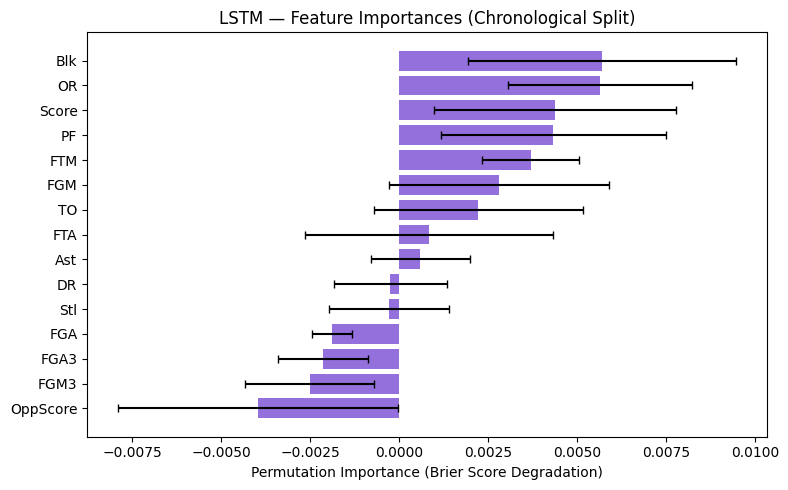

In [ ]:
# =============================================================================
# LSTM / RNN MODEL
# =============================================================================
# Approach: Unlike the other three models which use season-averaged features,
# the LSTM takes as input an ORDERED SEQUENCE of each team's last k=10 games
# (box score vectors) leading up to the tournament. This lets the model learn
# in-season momentum, fatigue, and trajectory that static averages cannot capture.
#
# For each matchup, we build two sequences (one per team), pass each through
# a shared LSTM encoder, concatenate the two hidden states, and feed into a
# small MLP head to produce a win probability.
#
# Steps:
#   1. Build per-game box score sequences for every team-season (last k games)
#   2. Construct matchup dataset pairing TeamA and TeamB sequences + label
#   3. Split data (chronological and random, same boundaries as Standard Import)
#   4. Define the LSTM architecture in PyTorch
#   5. Train with architecture sweep on validation Brier score
#   6. Evaluate best model on both test sets using evaluate_model()
#   7. Inspect feature importances via permutation on input features
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# STEP 1: Build Per-Game Box Score Sequences
# =============================================================================
# For each team in each season, we collect their regular season games in
# chronological order and keep the last K games before the tournament.
# Each game is represented as a box score vector from that team's perspective.
#
# Box score features per game (from that team's perspective):
#   Score, OppScore, FGM, FGA, FGM3, FGA3, FTM, FTA,
#   OR, DR, Ast, TO, Stl, Blk, PF
# That's 15 features per game step.

K = 10  # number of recent games to use as sequence

# ---- Reshape reg_season into team-perspective rows ----
# Each game produces two rows: one for the winner, one for the loser

def build_team_game_rows(reg_season):
    """
    Convert winner/loser format into one row per team per game.
    Returns a DataFrame with columns:
      Season, DayNum, TeamID, OppID,
      Score, OppScore, FGM, FGA, FGM3, FGA3, FTM, FTA,
      OR, DR, Ast, TO, Stl, Blk, PF
    """
    stat_cols = ['FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA',
                 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']

    # Winner rows
    win_rows = pd.DataFrame({
        'Season': reg_season['Season'],
        'DayNum': reg_season['DayNum'],
        'TeamID': reg_season['WTeamID'],
        'OppID':  reg_season['LTeamID'],
        'Score':    reg_season['WScore'],
        'OppScore': reg_season['LScore'],
    })
    for col in stat_cols:
        win_rows[col] = reg_season[f'W{col}'].values

    # Loser rows
    lose_rows = pd.DataFrame({
        'Season': reg_season['Season'],
        'DayNum': reg_season['DayNum'],
        'TeamID': reg_season['LTeamID'],
        'OppID':  reg_season['WTeamID'],
        'Score':    reg_season['LScore'],
        'OppScore': reg_season['WScore'],
    })
    for col in stat_cols:
        lose_rows[col] = reg_season[f'L{col}'].values

    combined = pd.concat([win_rows, lose_rows], ignore_index=True)
    combined  = combined.sort_values(['Season', 'TeamID', 'DayNum']).reset_index(drop=True)
    return combined

print("Building team-game rows from regular season box scores...")
team_games = build_team_game_rows(reg_season)

SEQ_FEATURE_COLS = ['Score', 'OppScore', 'FGM', 'FGA', 'FGM3', 'FGA3',
                    'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']
SEQ_DIM = len(SEQ_FEATURE_COLS)

print(f"Team-game rows: {len(team_games):,}")
print(f"Sequence features per game step: {SEQ_DIM}  {SEQ_FEATURE_COLS}")


# ---- Scale sequence features ----
# Fit scaler on ALL regular season games (we'll apply per-split below)
seq_scaler = StandardScaler()
seq_scaler.fit(team_games[SEQ_FEATURE_COLS])


# ---- Build sequence lookup: (Season, TeamID) -> np.array of shape (K, SEQ_DIM) ----
# For each team-season, take their last K regular season games.
# If a team played fewer than K games, left-pad with zeros.

def build_sequence_lookup(team_games, scaler, k=10):
    """
    Returns a dict: (Season, TeamID) -> np.array shape (k, SEQ_DIM)
    """
    lookup = {}
    scaled_vals = scaler.transform(team_games[SEQ_FEATURE_COLS])
    team_games  = team_games.copy()
    team_games[SEQ_FEATURE_COLS] = scaled_vals

    for (season, team_id), grp in team_games.groupby(['Season', 'TeamID']):
        grp   = grp.sort_values('DayNum')
        vecs  = grp[SEQ_FEATURE_COLS].values[-k:]        # last k games
        n     = len(vecs)
        if n < k:
            pad  = np.zeros((k - n, SEQ_DIM), dtype=np.float32)
            vecs = np.vstack([pad, vecs])
        lookup[(season, team_id)] = vecs.astype(np.float32)

    return lookup

print("\nBuilding sequence lookup (last 10 games per team-season)...")
seq_lookup = build_sequence_lookup(team_games, seq_scaler, k=K)
print(f"Lookup entries: {len(seq_lookup):,}  (team-seasons)")


# =============================================================================
# STEP 2: Build Matchup Dataset
# =============================================================================
# For each tournament matchup, retrieve TeamA's and TeamB's sequences.
# Output arrays:
#   seq_A : (N, K, SEQ_DIM)
#   seq_B : (N, K, SEQ_DIM)
#   labels: (N,)

def build_lstm_matchup_arrays(matchup_df, seq_lookup, k=10, seq_dim=15):
    """
    Build sequence arrays for all matchups in matchup_df.
    Returns seq_A, seq_B (both shape [N, K, SEQ_DIM]) and labels (shape [N]).
    """
    N      = len(matchup_df)
    seq_A  = np.zeros((N, k, seq_dim), dtype=np.float32)
    seq_B  = np.zeros((N, k, seq_dim), dtype=np.float32)
    labels = matchup_df['Label'].values.astype(np.float32)

    for i, row in enumerate(matchup_df.itertuples(index=False)):
        key_a = (row.Season, row.TeamA)
        key_b = (row.Season, row.TeamB)
        if key_a in seq_lookup:
            seq_A[i] = seq_lookup[key_a]
        if key_b in seq_lookup:
            seq_B[i] = seq_lookup[key_b]

    return seq_A, seq_B, labels

print("\nBuilding LSTM matchup arrays...")
lstm_seq_A, lstm_seq_B, lstm_labels = build_lstm_matchup_arrays(
    tourney_matchups, seq_lookup, k=K, seq_dim=SEQ_DIM
)
print(f"seq_A shape: {lstm_seq_A.shape}   (matchups x timesteps x features)")
print(f"seq_B shape: {lstm_seq_B.shape}")
print(f"Labels:      {lstm_labels.shape}  ({lstm_labels.mean()*100:.1f}% TeamA wins)")


# =============================================================================
# STEP 3: Split Data
# =============================================================================

# We need season info to do the chronological split
seasons_arr = tourney_matchups['Season'].values

# ---- Chronological split ----
chrono_train_mask = np.isin(seasons_arr, list(TRAIN_SEASONS))
chrono_val_mask   = np.isin(seasons_arr, list(VAL_SEASONS))
chrono_test_mask  = np.isin(seasons_arr, list(TEST_SEASONS))

lstm_seqA_chrono_train, lstm_seqB_chrono_train = lstm_seq_A[chrono_train_mask], lstm_seq_B[chrono_train_mask]
lstm_seqA_chrono_val,   lstm_seqB_chrono_val   = lstm_seq_A[chrono_val_mask],   lstm_seq_B[chrono_val_mask]
lstm_seqA_chrono_test,  lstm_seqB_chrono_test  = lstm_seq_A[chrono_test_mask],  lstm_seq_B[chrono_test_mask]
lstm_y_chrono_train = lstm_labels[chrono_train_mask]
lstm_y_chrono_val   = lstm_labels[chrono_val_mask]
lstm_y_chrono_test  = lstm_labels[chrono_test_mask]

# ---- Random split (70/15/15, SEED=573) ----
all_idx = np.arange(len(lstm_labels))
trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.15, random_state=SEED, stratify=lstm_labels
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=(15/85), random_state=SEED,
    stratify=lstm_labels[trainval_idx]
)

lstm_seqA_random_train, lstm_seqB_random_train = lstm_seq_A[train_idx], lstm_seq_B[train_idx]
lstm_seqA_random_val,   lstm_seqB_random_val   = lstm_seq_A[val_idx],   lstm_seq_B[val_idx]
lstm_seqA_random_test,  lstm_seqB_random_test  = lstm_seq_A[test_idx],  lstm_seq_B[test_idx]
lstm_y_random_train = lstm_labels[train_idx]
lstm_y_random_val   = lstm_labels[val_idx]
lstm_y_random_test  = lstm_labels[test_idx]

print(f"\nChrono split — Train: {lstm_y_chrono_train.shape[0]}, "
      f"Val: {lstm_y_chrono_val.shape[0]}, Test: {lstm_y_chrono_test.shape[0]}")
print(f"Random split — Train: {lstm_y_random_train.shape[0]}, "
      f"Val: {lstm_y_random_val.shape[0]}, Test: {lstm_y_random_test.shape[0]}")


# =============================================================================
# STEP 4: Define LSTM Architecture
# =============================================================================

class MatchupLSTM(nn.Module):
    """
    Dual-stream LSTM for tournament matchup prediction.

    Both teams share the same LSTM encoder weights. Their final hidden
    states are concatenated and passed through a small MLP head to
    produce a win probability.

    Architecture:
      TeamA sequence -> LSTM encoder -> h_A
      TeamB sequence -> LSTM encoder -> h_B
      [h_A | h_B | h_A - h_B] -> Linear -> ReLU -> Dropout -> Linear -> Sigmoid
    """
    def __init__(self, input_dim, hidden_dim, num_layers=1, dropout=0.3):
        super(MatchupLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,           # input shape: (batch, seq_len, features)
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # MLP head: takes concatenated + differenced hidden states
        head_input_dim = hidden_dim * 3  # [h_A | h_B | h_A - h_B]
        self.head = nn.Sequential(
            nn.Linear(head_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def encode(self, seq):
        """Run sequence through LSTM, return final hidden state."""
        _, (h_n, _) = self.lstm(seq)
        return h_n[-1]   # shape: (batch, hidden_dim)

    def forward(self, seq_a, seq_b):
        h_a = self.encode(seq_a)
        h_b = self.encode(seq_b)
        combined = torch.cat([h_a, h_b, h_a - h_b], dim=1)
        return self.head(combined).squeeze(1)


def make_lstm_loader(seqA, seqB, labels, batch_size=64, shuffle=True):
    """Create a DataLoader from sequence arrays and labels."""
    ds = TensorDataset(
        torch.tensor(seqA,   dtype=torch.float32),
        torch.tensor(seqB,   dtype=torch.float32),
        torch.tensor(labels, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_lstm(model, seqA_train, seqB_train, y_train,
               seqA_val, seqB_val, y_val,
               lr=1e-3, epochs=150, batch_size=64, patience=20):
    """
    Train the LSTM with early stopping on validation Brier score.
    Returns best validation Brier score achieved.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()
    loader    = make_lstm_loader(seqA_train, seqB_train, y_train,
                                 batch_size=batch_size, shuffle=True)

    seqA_val_t = torch.tensor(seqA_val, dtype=torch.float32)
    seqB_val_t = torch.tensor(seqB_val, dtype=torch.float32)
    y_val_t    = torch.tensor(y_val,    dtype=torch.float32)

    best_val_brier = float('inf')
    best_state     = None
    no_improve     = 0

    for epoch in range(epochs):
        model.train()
        for seqA_b, seqB_b, y_b in loader:
            optimizer.zero_grad()
            preds = model(seqA_b, seqB_b)
            loss  = criterion(preds, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(seqA_val_t, seqB_val_t).numpy()
            val_brier = np.mean((val_preds - y_val) ** 2)

        if val_brier < best_val_brier - 1e-5:
            best_val_brier = val_brier
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve     = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_brier


def predict_lstm(model, seqA, seqB):
    """Return probability predictions from a trained LSTM."""
    model.eval()
    with torch.no_grad():
        return model(
            torch.tensor(seqA, dtype=torch.float32),
            torch.tensor(seqB, dtype=torch.float32)
        ).numpy()


# =============================================================================
# STEP 5: Architecture Sweep on Validation Set
# =============================================================================
# We vary hidden size and number of LSTM layers, selecting the combo
# with the lowest validation Brier score.

architectures_lstm = [
    # (hidden_dim, num_layers, dropout)
    (64,  1, 0.3),
    (128, 1, 0.3),
    (128, 2, 0.3),
    (128, 2, 0.4),
    (256, 1, 0.3),
    (256, 2, 0.3),
    (256, 2, 0.4),
]

print("Sweeping LSTM architectures on chronological validation set...\n")
print(f"  {'Hidden':>8}  {'Layers':>6}  {'Dropout':>8}  {'Val Brier'}")
print("  " + "-" * 45)

best_lstm_brier   = float('inf')
best_lstm_hidden  = None
best_lstm_layers  = None
best_lstm_dropout = None

for hidden_dim, num_layers, dropout in architectures_lstm:
    torch.manual_seed(SEED)
    model = MatchupLSTM(SEQ_DIM, hidden_dim, num_layers, dropout)
    val_brier = train_lstm(
        model,
        lstm_seqA_chrono_train, lstm_seqB_chrono_train, lstm_y_chrono_train,
        lstm_seqA_chrono_val,   lstm_seqB_chrono_val,   lstm_y_chrono_val,
        lr=1e-3, epochs=200, batch_size=64, patience=25
    )
    marker = "  ← best" if val_brier < best_lstm_brier else ""
    print(f"  {hidden_dim:>8}  {num_layers:>6}  {dropout:>8.1f}  {val_brier:.4f}{marker}")

    if val_brier < best_lstm_brier:
        best_lstm_brier   = val_brier
        best_lstm_hidden  = hidden_dim
        best_lstm_layers  = num_layers
        best_lstm_dropout = dropout

print(f"\nBest: hidden={best_lstm_hidden}, layers={best_lstm_layers}, "
      f"dropout={best_lstm_dropout},  val Brier={best_lstm_brier:.4f}")


# =============================================================================
# STEP 6: Train Final Models and Evaluate on Both Splits
# =============================================================================

# ---- Chronological split ----
torch.manual_seed(SEED)
lstm_chrono = MatchupLSTM(SEQ_DIM, best_lstm_hidden, best_lstm_layers, best_lstm_dropout)
train_lstm(
    lstm_chrono,
    lstm_seqA_chrono_train, lstm_seqB_chrono_train, lstm_y_chrono_train,
    lstm_seqA_chrono_val,   lstm_seqB_chrono_val,   lstm_y_chrono_val,
    lr=1e-3, epochs=300, batch_size=64, patience=30
)
y_pred_lstm_chrono = predict_lstm(lstm_chrono, lstm_seqA_chrono_test, lstm_seqB_chrono_test)
evaluate_model(lstm_y_chrono_test, y_pred_lstm_chrono, "LSTM", "Chronological")

# ---- Random split — sweep on random val set ----
print("\nSweeping architectures on random validation set...\n")
print(f"  {'Hidden':>8}  {'Layers':>6}  {'Dropout':>8}  {'Val Brier'}")
print("  " + "-" * 45)

best_rand_lstm_brier   = float('inf')
best_rand_lstm_hidden  = None
best_rand_lstm_layers  = None
best_rand_lstm_dropout = None

for hidden_dim, num_layers, dropout in architectures_lstm:
    torch.manual_seed(SEED)
    model = MatchupLSTM(SEQ_DIM, hidden_dim, num_layers, dropout)
    val_brier = train_lstm(
        model,
        lstm_seqA_random_train, lstm_seqB_random_train, lstm_y_random_train,
        lstm_seqA_random_val,   lstm_seqB_random_val,   lstm_y_random_val,
        lr=1e-3, epochs=200, batch_size=64, patience=25
    )
    marker = "  ← best" if val_brier < best_rand_lstm_brier else ""
    print(f"  {hidden_dim:>8}  {num_layers:>6}  {dropout:>8.1f}  {val_brier:.4f}{marker}")

    if val_brier < best_rand_lstm_brier:
        best_rand_lstm_brier   = val_brier
        best_rand_lstm_hidden  = hidden_dim
        best_rand_lstm_layers  = num_layers
        best_rand_lstm_dropout = dropout

torch.manual_seed(SEED)
lstm_random = MatchupLSTM(SEQ_DIM, best_rand_lstm_hidden,
                          best_rand_lstm_layers, best_rand_lstm_dropout)
train_lstm(
    lstm_random,
    lstm_seqA_random_train, lstm_seqB_random_train, lstm_y_random_train,
    lstm_seqA_random_val,   lstm_seqB_random_val,   lstm_y_random_val,
    lr=1e-3, epochs=300, batch_size=64, patience=30
)
y_pred_lstm_random = predict_lstm(lstm_random, lstm_seqA_random_test, lstm_seqB_random_test)
evaluate_model(lstm_y_random_test, y_pred_lstm_random, "LSTM", "Random")


# =============================================================================
# STEP 7: Feature Importance via Permutation on Input Features
# =============================================================================
# We permute one input feature (across all timesteps) at a time and measure
# how much the Brier score degrades. Larger degradation = more important.

print("\nComputing permutation importances (LSTM, chronological model)...")

baseline_preds = predict_lstm(lstm_chrono, lstm_seqA_chrono_test, lstm_seqB_chrono_test)
baseline_brier = np.mean((baseline_preds - lstm_y_chrono_test) ** 2)
print(f"Baseline Brier: {baseline_brier:.4f}")

n_repeats = 20
lstm_imp_mean = []
lstm_imp_std  = []

for i, feat in enumerate(SEQ_FEATURE_COLS):
    repeat_scores = []
    for _ in range(n_repeats):
        # Permute feature i across all timesteps and all matchups for TeamA
        seqA_perm = lstm_seqA_chrono_test.copy()
        perm_idx  = np.random.permutation(seqA_perm.shape[0])
        seqA_perm[:, :, i] = seqA_perm[perm_idx, :, i]

        # Also permute for TeamB
        seqB_perm = lstm_seqB_chrono_test.copy()
        perm_idx  = np.random.permutation(seqB_perm.shape[0])
        seqB_perm[:, :, i] = seqB_perm[perm_idx, :, i]

        perm_preds = predict_lstm(lstm_chrono, seqA_perm, seqB_perm)
        perm_brier = np.mean((perm_preds - lstm_y_chrono_test) ** 2)
        repeat_scores.append(perm_brier - baseline_brier)

    lstm_imp_mean.append(np.mean(repeat_scores))
    lstm_imp_std.append(np.std(repeat_scores))

feat_importance_lstm = pd.DataFrame({
    'Feature':    SEQ_FEATURE_COLS,
    'Importance': lstm_imp_mean,
    'Std':        lstm_imp_std,
}).sort_values('Importance', ascending=False)

# ---- Print results ----
print("\nFeature Importances (LSTM, permutation, Chronological):")
print("-" * 55)
max_imp = max(feat_importance_lstm['Importance'].max(), 1e-9)
for _, row in feat_importance_lstm.iterrows():
    bar = "█" * max(0, int(row['Importance'] / max_imp * 30))
    print(f"  {row['Feature']:<12s} {row['Importance']:7.4f} ± {row['Std']:.4f}  {bar}")

# ---- Plot ----
feat_imp_plot = feat_importance_lstm.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp_plot['Feature'], feat_imp_plot['Importance'],
        xerr=feat_imp_plot['Std'], color='mediumpurple', capsize=3)
ax.set_xlabel('Permutation Importance (Brier Score Degradation)')
ax.set_title('LSTM — Feature Importances (Chronological Split)')
plt.tight_layout()
plt.show()

# Final Results Comparison

In [ ]:
# =============================================================================
# Run this cell AFTER all group members have evaluated their models above.
# It prints the full comparison table (4 models x 2 splits + baselines).
# =============================================================================

all_results = [] # Initialize all_results to avoid NameError
all_results.clear()

# Re-register all results in order
evaluate_model(y_chrono_test, np.full(len(y_chrono_test), 0.5), "Baseline (p=0.5)", "Chronological")
evaluate_model(y_random_test, np.full(len(y_random_test), 0.5), "Baseline (p=0.5)", "Random")
evaluate_model(y_chrono_test, chrono_seed_proba, "Baseline (Seed)", "Chronological")
evaluate_model(y_random_test, random_seed_proba, "Baseline (Seed)", "Random")
evaluate_model(y_rf_chrono_test,   y_pred_chrono,       "Random Forest", "Chronological")
evaluate_model(y_rf_random_test,   y_pred_random,       "Random Forest", "Random")
evaluate_model(y_xgb_chrono_test,  y_pred_xgb_chrono,   "XGBoost",       "Chronological")
evaluate_model(y_xgb_random_test,  y_pred_xgb_random,   "XGBoost",       "Random")
evaluate_model(y_ffnn_chrono_test, y_pred_ffnn_chrono,  "FFNN",          "Chronological")
evaluate_model(y_ffnn_random_test, y_pred_ffnn_random,  "FFNN",          "Random")
evaluate_model(lstm_y_chrono_test, y_pred_lstm_chrono,  "LSTM",          "Chronological")
evaluate_model(lstm_y_random_test, y_pred_lstm_random,  "LSTM",          "Random")

# Now show the clean table
show_all_results()

NameError: name 'evaluate_model' is not defined